# Evaluation Analysis

This notebook analyses the latest evaluation outputs from the standalone pipeline scripts.

It covers:
- accuracy evaluation (`accuracy_eval_*.csv`)
- timing analysis from orchestrator timings
- evaluator effectiveness (`evaluator_eval_*.csv`)
- optional comparison across multiple accuracy runs

All generated figures are saved into `results/figures/`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "scripts").exists() and (REPO_ROOT.parent / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.analysis_helpers import (
    available_numeric_columns,
    build_figure_filename,
    compute_p95,
    ensure_figures_dir,
    extract_timestamp_from_filename,
    find_latest_csv,
    grouped_averages_by_category,
    load_accuracy_run_comparison,
    load_csv_safe,
    round_numeric_dataframe,
    save_and_display_figure,
    save_figure,
)

results_dir = REPO_ROOT / "results"
figures_dir = ensure_figures_dir(results_dir / "figures")

# Set one or both of these if you want to analyse a specific file.
accuracy_filename = None
evaluator_filename = None

accuracy_path = Path(accuracy_filename) if accuracy_filename else find_latest_csv("accuracy_eval_", results_dir=results_dir)
evaluator_path = Path(evaluator_filename) if evaluator_filename else find_latest_csv("evaluator_eval_", results_dir=results_dir)

if accuracy_path is None:
    raise FileNotFoundError("No accuracy evaluation CSV files were found in results/.")
if evaluator_path is None:
    raise FileNotFoundError("No evaluator evaluation CSV files were found in results/.")

print(f"Accuracy CSV: {accuracy_path.name}")
print(f"Accuracy timestamp: {extract_timestamp_from_filename(accuracy_path.name)}")
print(f"Evaluator CSV: {evaluator_path.name}")
print(f"Evaluator timestamp: {extract_timestamp_from_filename(evaluator_path.name)}")
print(f"Figures directory: {figures_dir}")


def numeric_values(dataframe: pd.DataFrame, column: str) -> pd.Series:
    return pd.to_numeric(dataframe[column], errors="coerce").dropna()


def axis_note(ax, title: str, message: str) -> None:
    ax.set_title(title)
    ax.text(0.5, 0.5, message, ha="center", va="center", wrap=True)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def signature_payload(chart_key: str, data: object, extra: object = None) -> dict:
    payload = {"chart_key": chart_key, "data": data}
    if extra is not None:
        payload["extra"] = extra
    return payload


def display_saved_figure_gallery(paths: list[Path], *, title: str = "Generated figures") -> None:
    valid_paths = [Path(item) for item in paths if item and Path(item).exists()]
    if not valid_paths:
        print(f"No saved figures were found for: {title}")
        return

    print(title)
    for figure_path in valid_paths:
        print(f"- {figure_path.name}")
        display(Image(filename=str(figure_path)))


Accuracy CSV: accuracy_eval_20260414_162339.csv
Accuracy timestamp: 2026-04-14 16:23:39
Evaluator CSV: evaluator_eval_20260414_173926.csv
Evaluator timestamp: 2026-04-14 17:39:26
Figures directory: C:\Users\Emman\OneDrive\Documents\GitHub\PartD_GroupProject\results\figures


## Accuracy Evaluation

This section loads the accuracy evaluation CSV, previews the data, computes overall and per-category RAGAS metrics, and saves report-ready figures.

,id,category,question,ground_truth_answer,generated_answer,retrieved_context_count,faithfulness,answer_relevancy,context_precision,context_recall,...,processor_time_ms,retriever_time_ms,answerer_time_ms,evaluator_time_ms,total_time_ms,evaluator_decision,retry_count,success,error_message,metric_error_message
0,accommodation_01,accommodation,How much is Butler Court?,Butler Court prices for 2025/26 start at GBP 1...,The prices for Butler Court are as follows: GB...,8,1.0,0.842639,1.000,1.000000,...,1311.614,680.735,1642.524,2.423,4105.101,pass,0,True,NaN,NaN
1,accommodation_02,accommodation,Does Butler Court have en-suite rooms?,"Yes. Butler Court offers en-suite room types, ...",Butler Court does not have en-suite rooms. The...,8,1.0,0.806747,1.000,1.000000,...,1419.933,266.114,1145.875,1.353,3145.332,pass,0,True,NaN,NaN
2,accommodation_03,accommodation,Is Butler Court catered?,No. Butler Court is self-catered.,Butler Court is self-catered and does not offe...,8,1.0,0.804818,0.625,0.500000,...,1080.122,248.067,1313.267,0.990,3122.129,pass,0,True,NaN,NaN
3,accommodation_04,accommodation,Where is Butler Court located?,"Butler Court is in East Park, near the School ...",Butler Court is located at Butler Court Loughb...,8,1.0,0.999999,1.000,1.000000,...,1697.257,255.999,1511.210,1.027,3931.995,pass,0,True,NaN,NaN
4,accommodation_05,accommodation,"Which is cheaper, Butler Court or Cayley?",Butler Court is cheaper. Its lowest listed wee...,I couldn't verify a reliable answer from the a...,10,0.5,0.000000,0.100,0.666667,...,1350.805,470.391,2713.954,3990.005,9102.198,fallback,1,True,NaN,NaN


Number of questions: 30


,metric,average
0,faithfulness,0.936
1,answer_relevancy,0.704
2,context_precision,0.796
3,context_recall,0.956


,category,faithfulness,answer_relevancy,context_precision,context_recall
0,accommodation,0.940,0.664,0.767,0.917
1,contextual_policy,0.967,0.666,0.866,0.950
2,undergraduate_courses,0.900,0.782,0.757,1.000


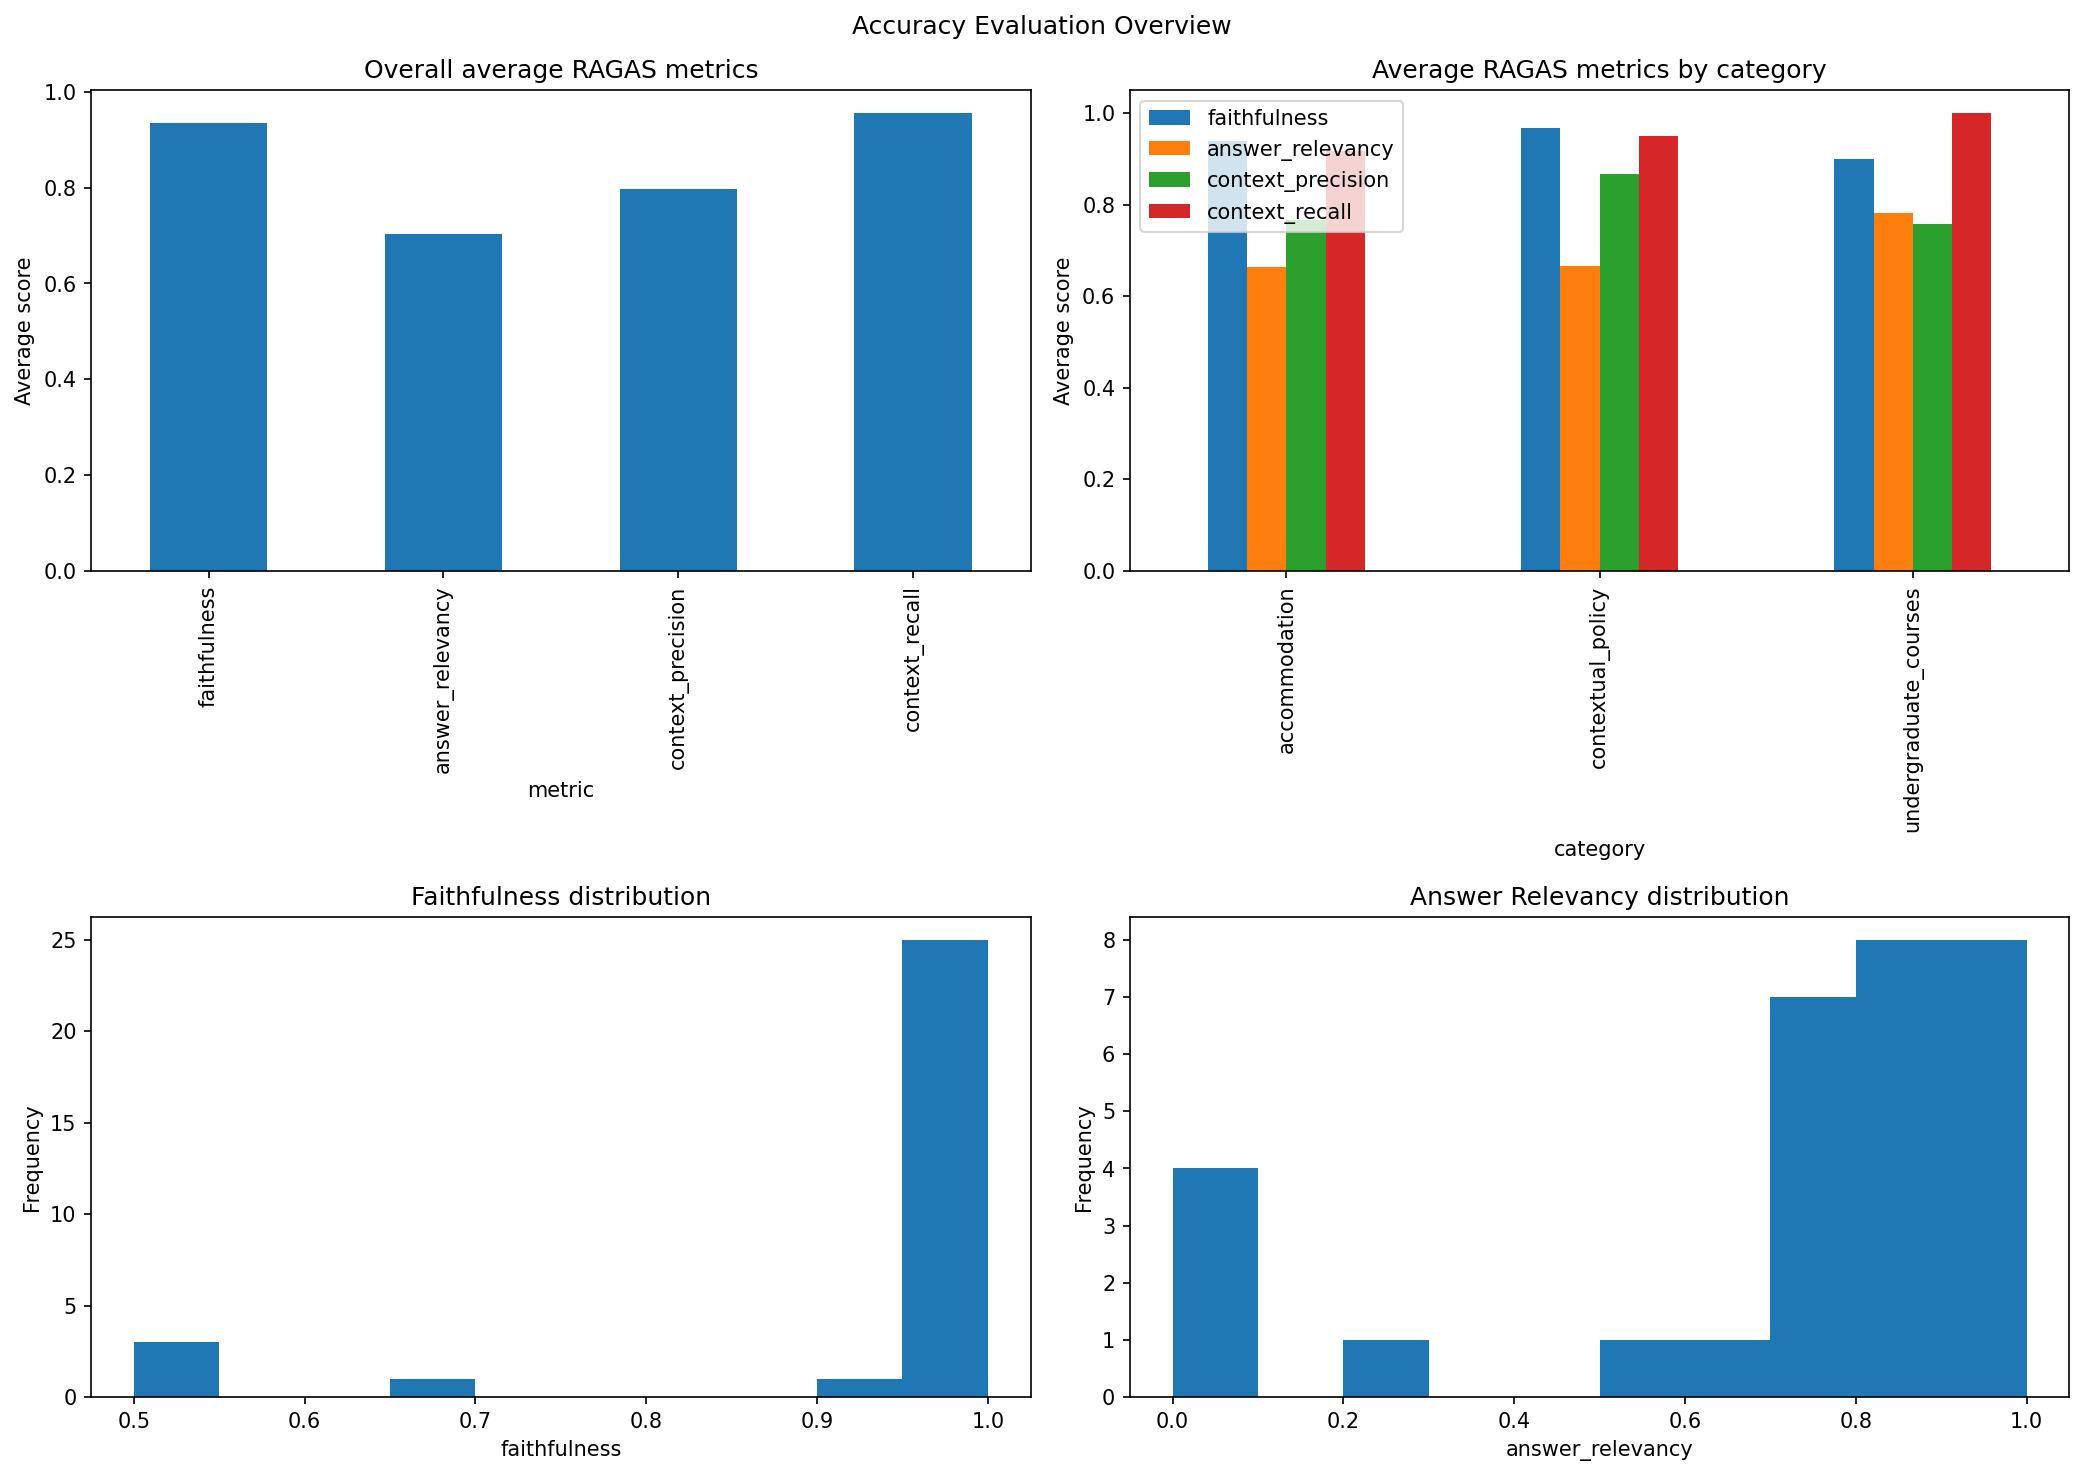

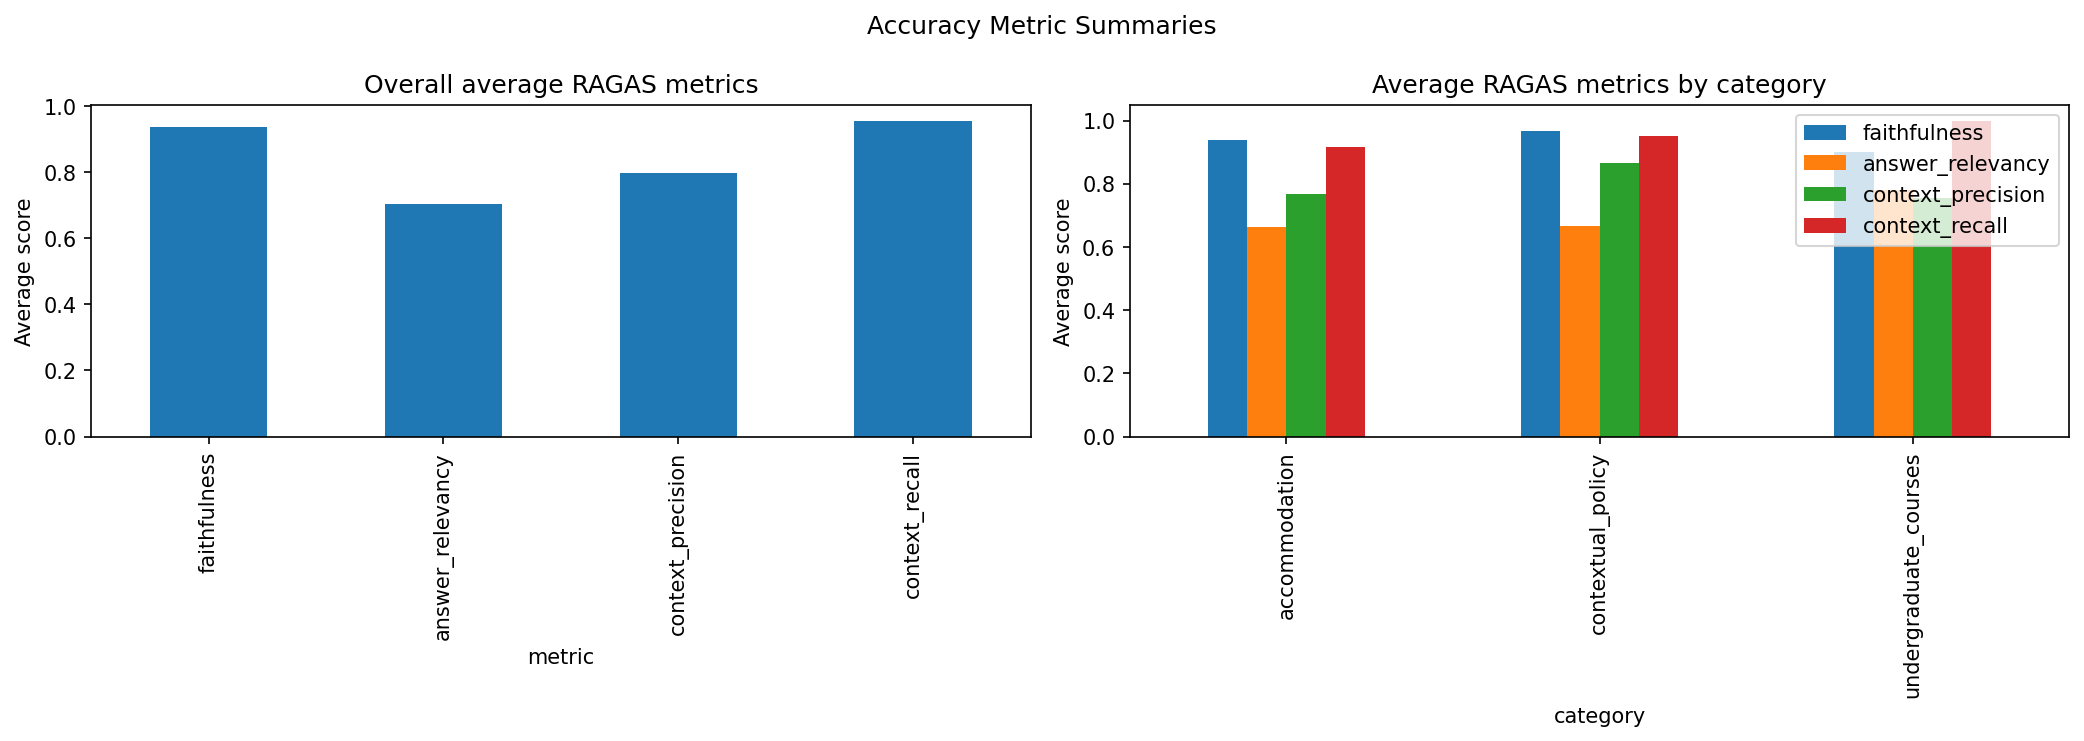

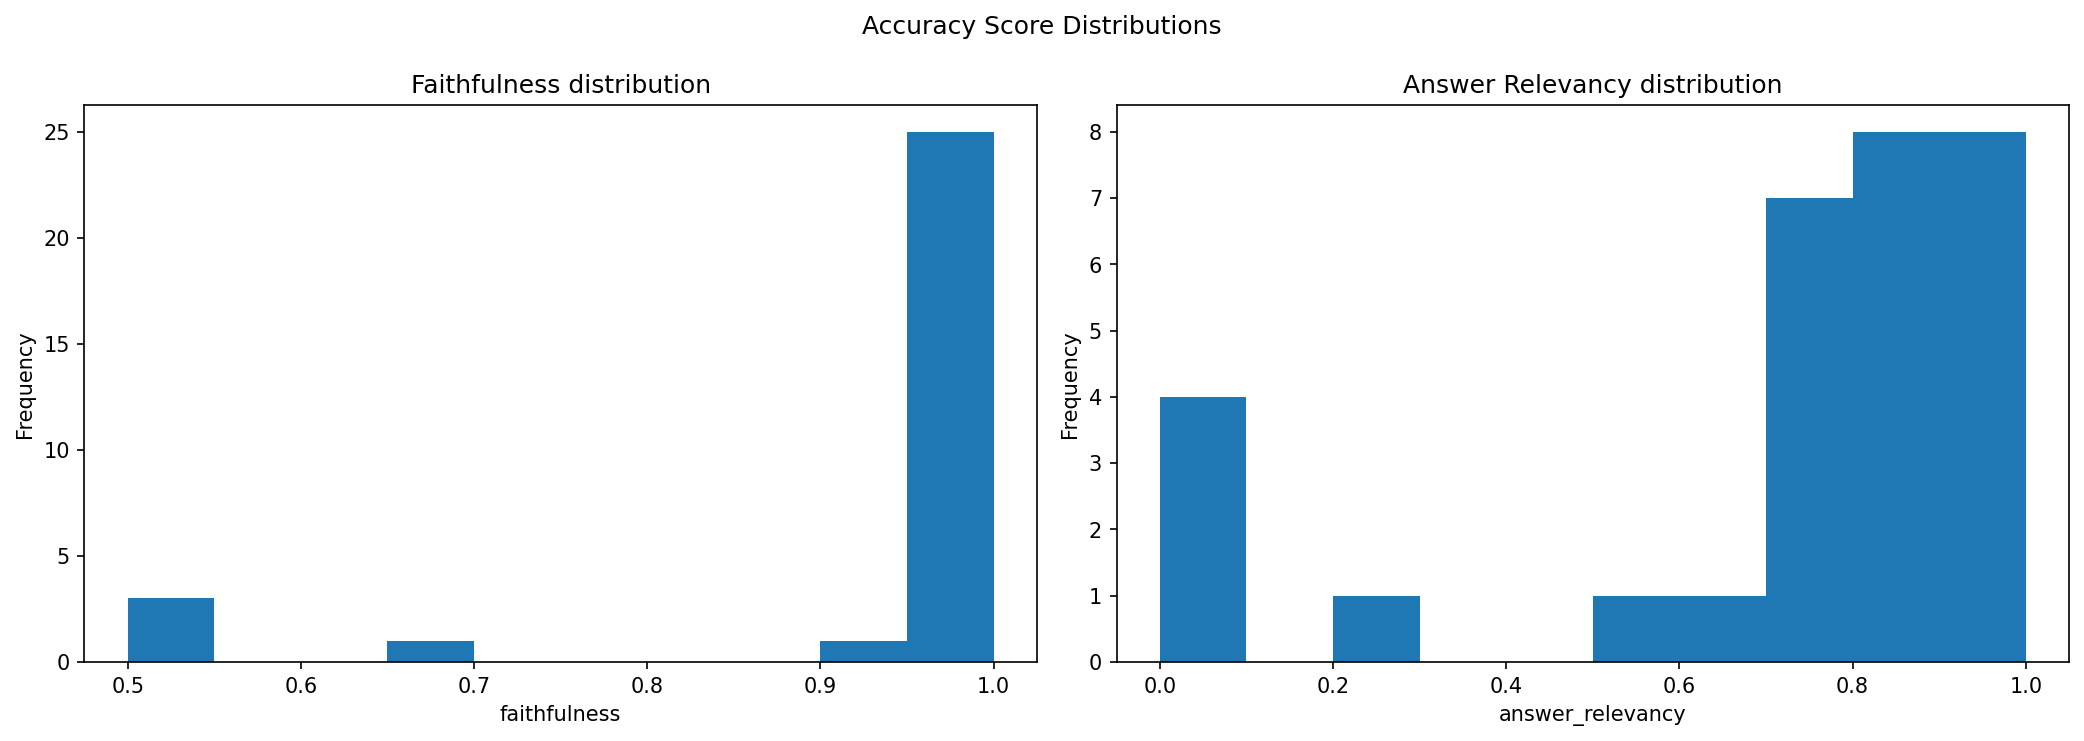

In [2]:
accuracy_df = load_csv_safe(accuracy_path)
display(accuracy_df.head())

ragas_columns = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
available_ragas = available_numeric_columns(accuracy_df, ragas_columns)

if not available_ragas:
    print("No RAGAS metric columns were available in the selected accuracy CSV.")
else:
    overall_ragas = pd.DataFrame(
        {
            "metric": available_ragas,
            "average": [pd.to_numeric(accuracy_df[column], errors="coerce").mean() for column in available_ragas],
        }
    )
    print(f"Number of questions: {len(accuracy_df)}")
    display(round_numeric_dataframe(overall_ragas))

    fig, ax = plt.subplots()
    overall_ragas.set_index("metric")["average"].plot(kind="bar", ax=ax)
    ax.set_title("Overall average RAGAS metrics")
    ax.set_ylabel("Average score")
    save_figure(fig, f"{accuracy_path.stem}_overall_ragas_metrics.png", output_dir=figures_dir, signature_parts=signature_payload("accuracy_overall_ragas", overall_ragas))

    per_category_ragas = grouped_averages_by_category(accuracy_df, available_ragas)
    if not per_category_ragas.empty:
        display(round_numeric_dataframe(per_category_ragas))
        fig, ax = plt.subplots()
        per_category_ragas.set_index("category").plot(kind="bar", ax=ax)
        ax.set_title("Average RAGAS metrics by category")
        ax.set_ylabel("Average score")
        save_figure(fig, f"{accuracy_path.stem}_ragas_metrics_by_category.png", output_dir=figures_dir, signature_parts=signature_payload("accuracy_ragas_by_category", per_category_ragas))

    histogram_values = {}
    for column in ["faithfulness", "answer_relevancy"]:
        if column not in accuracy_df.columns:
            print(f"Skipping histogram because '{column}' is missing.")
            continue
        values = numeric_values(accuracy_df, column)
        if values.empty:
            print(f"Skipping histogram because '{column}' had no numeric values.")
            continue
        histogram_values[column] = values
        fig, ax = plt.subplots()
        values.plot(kind="hist", bins=10, ax=ax)
        ax.set_title(f"{column.replace('_', ' ').title()} distribution")
        ax.set_xlabel(column)
        save_figure(fig, f"{accuracy_path.stem}_{column}_histogram.png", output_dir=figures_dir, signature_parts=signature_payload(f"accuracy_{column}_histogram", values.tolist()))

    overview_fig, overview_axes = plt.subplots(2, 2, figsize=(14, 10))
    overall_ragas.set_index("metric")["average"].plot(kind="bar", ax=overview_axes[0, 0])
    overview_axes[0, 0].set_title("Overall average RAGAS metrics")
    overview_axes[0, 0].set_ylabel("Average score")

    if not per_category_ragas.empty:
        per_category_ragas.set_index("category").plot(kind="bar", ax=overview_axes[0, 1])
        overview_axes[0, 1].set_title("Average RAGAS metrics by category")
        overview_axes[0, 1].set_ylabel("Average score")
    else:
        axis_note(overview_axes[0, 1], "Average RAGAS metrics by category", "Category data was unavailable for this run.")

    for axis, column in zip(overview_axes[1], ["faithfulness", "answer_relevancy"]):
        values = histogram_values.get(column)
        if values is None or values.empty:
            axis_note(axis, f"{column.replace('_', ' ').title()} distribution", "No numeric values were available.")
            continue
        values.plot(kind="hist", bins=10, ax=axis)
        axis.set_title(f"{column.replace('_', ' ').title()} distribution")
        axis.set_xlabel(column)

    overview_fig.suptitle("Accuracy Evaluation Overview")
    overview_fig.tight_layout()
    save_and_display_figure(overview_fig, build_figure_filename(accuracy_path.stem, "accuracy", "overview"), output_dir=figures_dir, signature_parts=signature_payload("accuracy_overview", {"overall_ragas": overall_ragas, "per_category_ragas": per_category_ragas, "histograms": {key: value.tolist() for key, value in histogram_values.items()}}))

    grouped_metrics_fig, grouped_metrics_axes = plt.subplots(1, 2, figsize=(14, 5))
    overall_ragas.set_index("metric")["average"].plot(kind="bar", ax=grouped_metrics_axes[0])
    grouped_metrics_axes[0].set_title("Overall average RAGAS metrics")
    grouped_metrics_axes[0].set_ylabel("Average score")

    if not per_category_ragas.empty:
        per_category_ragas.set_index("category").plot(kind="bar", ax=grouped_metrics_axes[1])
        grouped_metrics_axes[1].set_title("Average RAGAS metrics by category")
        grouped_metrics_axes[1].set_ylabel("Average score")
    else:
        axis_note(grouped_metrics_axes[1], "Average RAGAS metrics by category", "Category data was unavailable for this run.")

    grouped_metrics_fig.suptitle("Accuracy Metric Summaries")
    grouped_metrics_fig.tight_layout()
    save_and_display_figure(grouped_metrics_fig, build_figure_filename(accuracy_path.stem, "accuracy", "grouped_metrics"), output_dir=figures_dir, signature_parts=signature_payload("accuracy_grouped_metrics", {"overall_ragas": overall_ragas, "per_category_ragas": per_category_ragas}))

    grouped_distribution_fig, grouped_distribution_axes = plt.subplots(1, 2, figsize=(14, 5))
    for axis, column in zip(grouped_distribution_axes, ["faithfulness", "answer_relevancy"]):
        values = histogram_values.get(column)
        if values is None or values.empty:
            axis_note(axis, f"{column.replace('_', ' ').title()} distribution", "No numeric values were available.")
            continue
        values.plot(kind="hist", bins=10, ax=axis)
        axis.set_title(f"{column.replace('_', ' ').title()} distribution")
        axis.set_xlabel(column)

    grouped_distribution_fig.suptitle("Accuracy Score Distributions")
    grouped_distribution_fig.tight_layout()
    save_and_display_figure(grouped_distribution_fig, build_figure_filename(accuracy_path.stem, "accuracy", "grouped_distributions"), output_dir=figures_dir, signature_parts=signature_payload("accuracy_grouped_distributions", {"histograms": {key: value.tolist() for key, value in histogram_values.items()}}))


## Timing Analysis

This section uses the orchestrator timing columns to summarise stage-level latency and overall end-to-end response time.

,stage,mean,median,min,max,p95
0,processor_time_ms,1478.152,1346.555,1060.491,3071.267,2231.815
1,retriever_time_ms,405.172,385.178,223.591,928.363,672.814
2,answerer_time_ms,2813.311,2146.096,1.372,7813.891,6709.763
3,evaluator_time_ms,137.562,4.912,0.990,3990.005,12.482
4,total_time_ms,5201.587,4348.448,2810.178,10562.634,9549.495


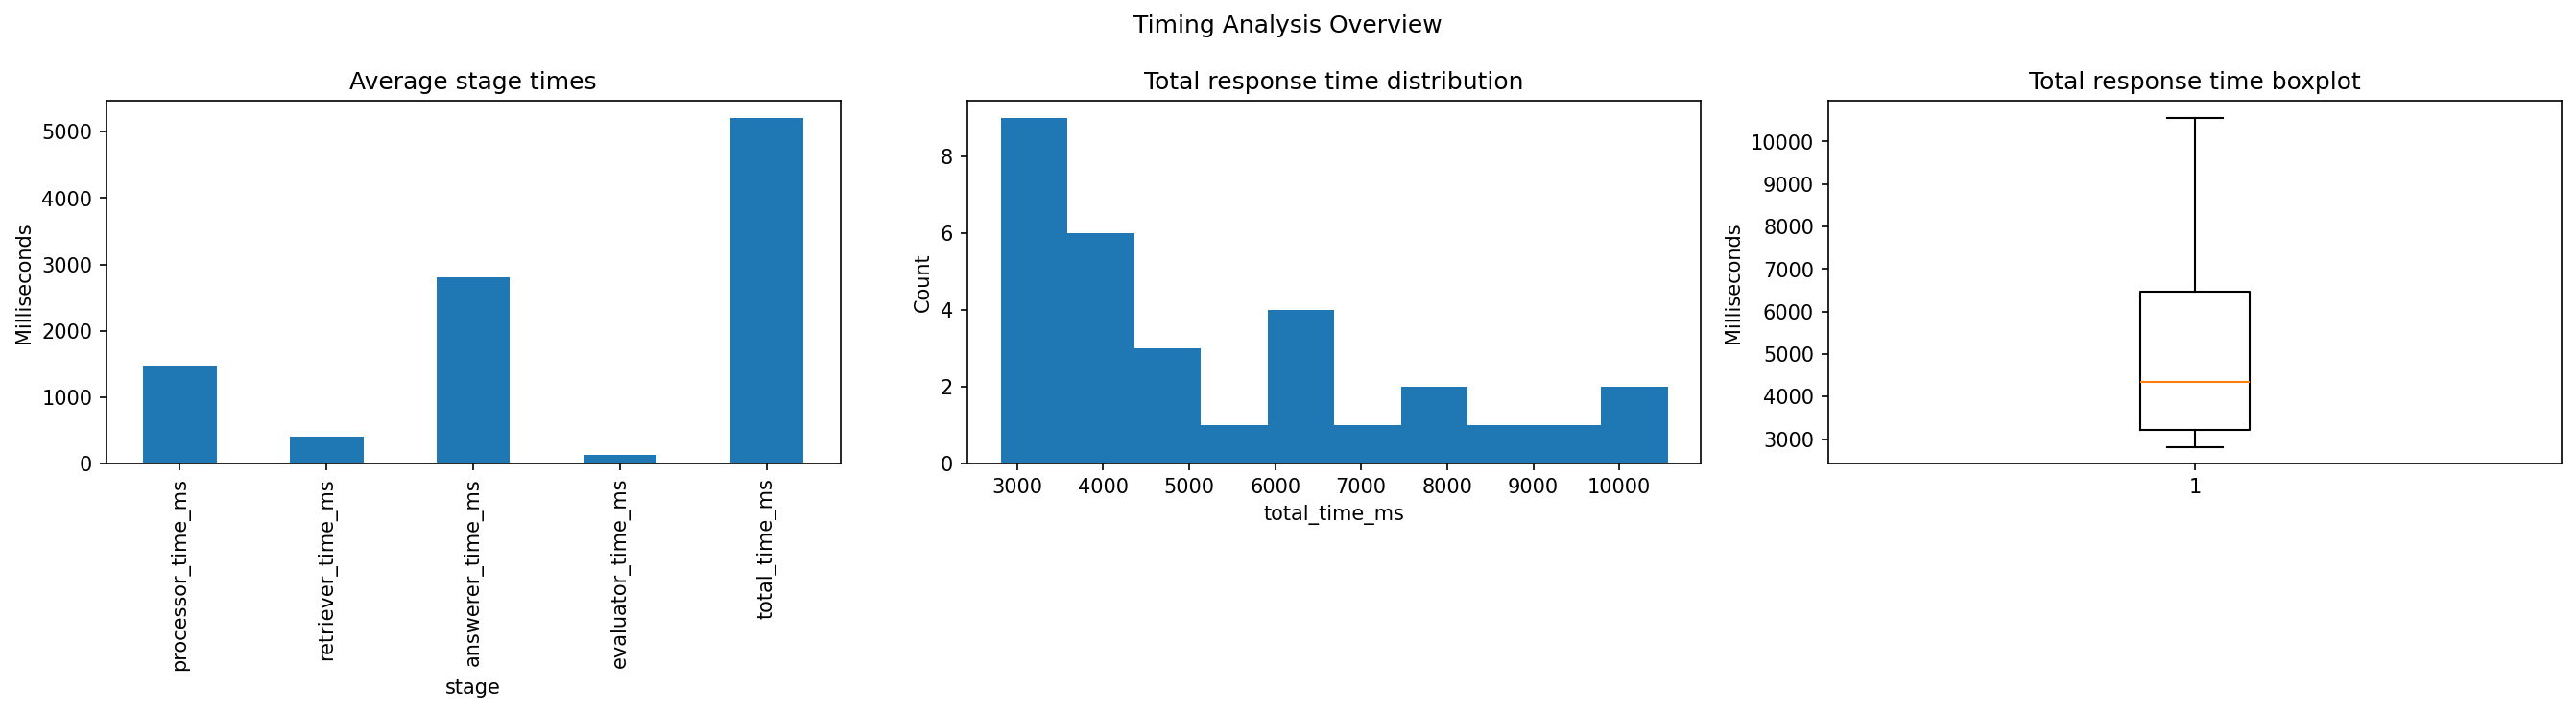

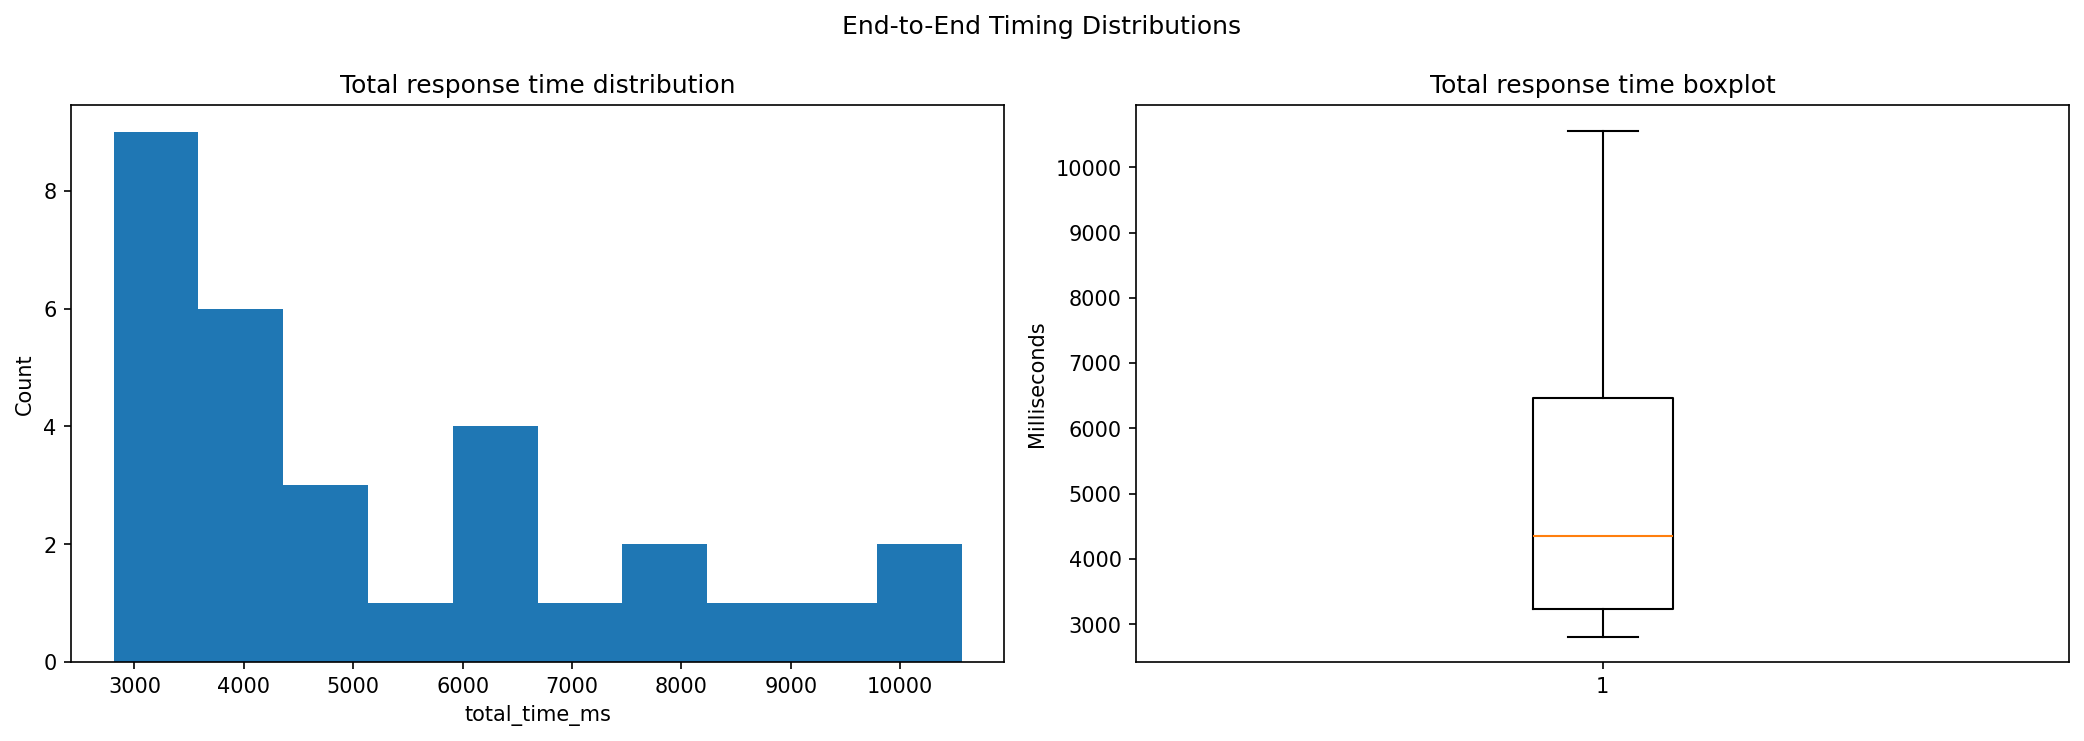

In [3]:
timing_columns = [
    "processor_time_ms",
    "retriever_time_ms",
    "answerer_time_ms",
    "evaluator_time_ms",
    "total_time_ms",
]
available_timing = available_numeric_columns(accuracy_df, timing_columns)

if not available_timing:
    print("No timing columns were available in the selected accuracy CSV.")
else:
    timing_summary = pd.DataFrame([
        {
            "stage": column,
            "mean": pd.to_numeric(accuracy_df[column], errors="coerce").mean(),
            "median": pd.to_numeric(accuracy_df[column], errors="coerce").median(),
            "min": pd.to_numeric(accuracy_df[column], errors="coerce").min(),
            "max": pd.to_numeric(accuracy_df[column], errors="coerce").max(),
            "p95": compute_p95(pd.to_numeric(accuracy_df[column], errors="coerce")),
        }
        for column in available_timing
    ])
    display(round_numeric_dataframe(timing_summary))

    fig, ax = plt.subplots()
    timing_summary.set_index("stage")["mean"].plot(kind="bar", ax=ax)
    ax.set_title("Average stage times")
    ax.set_ylabel("Milliseconds")
    save_figure(fig, f"{accuracy_path.stem}_average_stage_times.png", output_dir=figures_dir, signature_parts=signature_payload("timing_average_stage_times", timing_summary))

    total_times = pd.Series(dtype="float64")
    if "total_time_ms" in accuracy_df.columns:
        total_times = numeric_values(accuracy_df, "total_time_ms")
        if not total_times.empty:
            fig, ax = plt.subplots()
            total_times.plot(kind="hist", bins=10, ax=ax)
            ax.set_title("Total response time distribution")
            ax.set_xlabel("total_time_ms")
            save_figure(fig, f"{accuracy_path.stem}_total_time_histogram.png", output_dir=figures_dir, signature_parts=signature_payload("timing_total_time_histogram", total_times.tolist()))

            fig, ax = plt.subplots()
            ax.boxplot(total_times)
            ax.set_title("Total response time boxplot")
            ax.set_ylabel("Milliseconds")
            save_figure(fig, f"{accuracy_path.stem}_total_time_boxplot.png", output_dir=figures_dir, signature_parts=signature_payload("timing_total_time_boxplot", total_times.tolist()))

    overview_fig, overview_axes = plt.subplots(1, 3, figsize=(18, 5))
    timing_summary.set_index("stage")["mean"].plot(kind="bar", ax=overview_axes[0])
    overview_axes[0].set_title("Average stage times")
    overview_axes[0].set_ylabel("Milliseconds")

    if total_times.empty:
        axis_note(overview_axes[1], "Total response time distribution", "No numeric total_time_ms values were available.")
        axis_note(overview_axes[2], "Total response time boxplot", "No numeric total_time_ms values were available.")
    else:
        total_times.plot(kind="hist", bins=10, ax=overview_axes[1])
        overview_axes[1].set_title("Total response time distribution")
        overview_axes[1].set_xlabel("total_time_ms")
        overview_axes[1].set_ylabel("Count")
        overview_axes[2].boxplot(total_times)
        overview_axes[2].set_title("Total response time boxplot")
        overview_axes[2].set_ylabel("Milliseconds")

    overview_fig.suptitle("Timing Analysis Overview")
    overview_fig.tight_layout()
    save_and_display_figure(overview_fig, build_figure_filename(accuracy_path.stem, "timing", "overview"), output_dir=figures_dir, signature_parts=signature_payload("timing_overview", {"timing_summary": timing_summary, "total_times": total_times.tolist()}))

    distribution_fig, distribution_axes = plt.subplots(1, 2, figsize=(14, 5))
    if total_times.empty:
        axis_note(distribution_axes[0], "Total response time distribution", "No numeric total_time_ms values were available.")
        axis_note(distribution_axes[1], "Total response time boxplot", "No numeric total_time_ms values were available.")
    else:
        total_times.plot(kind="hist", bins=10, ax=distribution_axes[0])
        distribution_axes[0].set_title("Total response time distribution")
        distribution_axes[0].set_xlabel("total_time_ms")
        distribution_axes[0].set_ylabel("Count")
        distribution_axes[1].boxplot(total_times)
        distribution_axes[1].set_title("Total response time boxplot")
        distribution_axes[1].set_ylabel("Milliseconds")

    distribution_fig.suptitle("End-to-End Timing Distributions")
    distribution_fig.tight_layout()
    save_and_display_figure(distribution_fig, build_figure_filename(accuracy_path.stem, "timing", "grouped_distributions"), output_dir=figures_dir, signature_parts=signature_payload("timing_grouped_distributions", total_times.tolist()))


## Evaluator Effectiveness

This section analyses the evaluator decision output, decision percentages, and retry distribution.

,id,category,question,evaluator_decision,initial_verdict,final_verdict,effective_verdict,runtime_action,retry_count,fallback_used,...,suggested_action,suggested_filters,clarification_question,notes,attempt_used,result_count,retrieved_result_count,attempts_log,success,error_message
0,accommodation_01,accommodation,How much is Butler Court?,pass,pass,pass,pass,pass,0,False,...,accept_answer,NaN,NaN,"Evidence count=8, top_score=1.300, avg_top3=0....",1,8,8,"[{""attempt"": 1, ""description"": ""initial:full_p...",True,NaN
1,accommodation_02,accommodation,Does Butler Court have en-suite rooms?,pass,pass,pass,pass,pass,0,False,...,accept_answer,NaN,NaN,"Evidence count=8, top_score=1.300, avg_top3=0....",1,8,8,"[{""attempt"": 1, ""description"": ""initial:full_p...",True,NaN
2,accommodation_03,accommodation,Is Butler Court catered?,pass,pass,pass,pass,pass,0,False,...,accept_answer,NaN,NaN,"Evidence count=8, top_score=1.300, avg_top3=0....",1,8,8,"[{""attempt"": 1, ""description"": ""initial:full_p...",True,NaN
3,accommodation_04,accommodation,Where is Butler Court located?,pass,pass,pass,pass,pass,0,False,...,accept_answer,NaN,NaN,"Evidence count=8, top_score=1.300, avg_top3=1....",1,8,8,"[{""attempt"": 1, ""description"": ""initial:full_p...",True,NaN
4,accommodation_05,accommodation,"Which is cheaper, Butler Court or Cayley?",fallback,revise,revise,fallback,fallback,1,True,...,revise_answer,NaN,NaN,"Evidence count=10, top_score=1.274, avg_top3=1...",2,10,10,"[{""attempt"": 1, ""description"": ""initial:full_p...",True,NaN


,decision,count,percentage
0,fallback,3,10.0
1,pass,27,90.0


,retry_count,questions
0,0,27
1,1,3


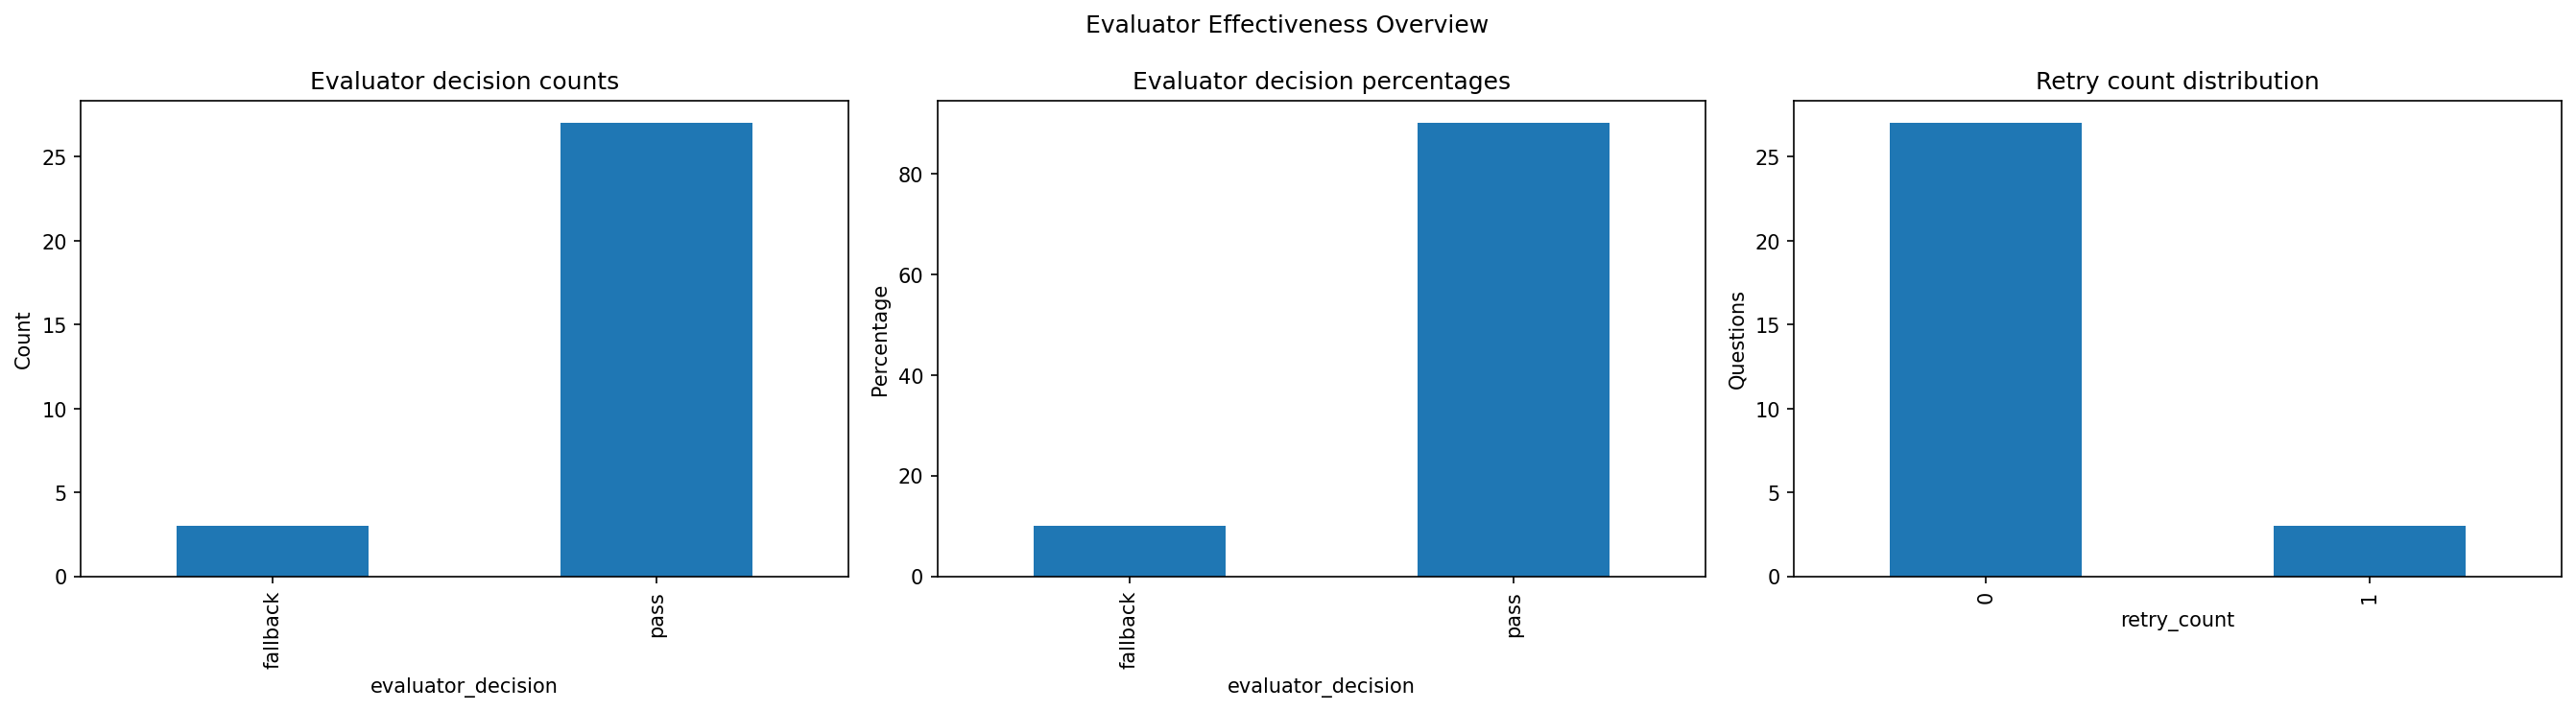

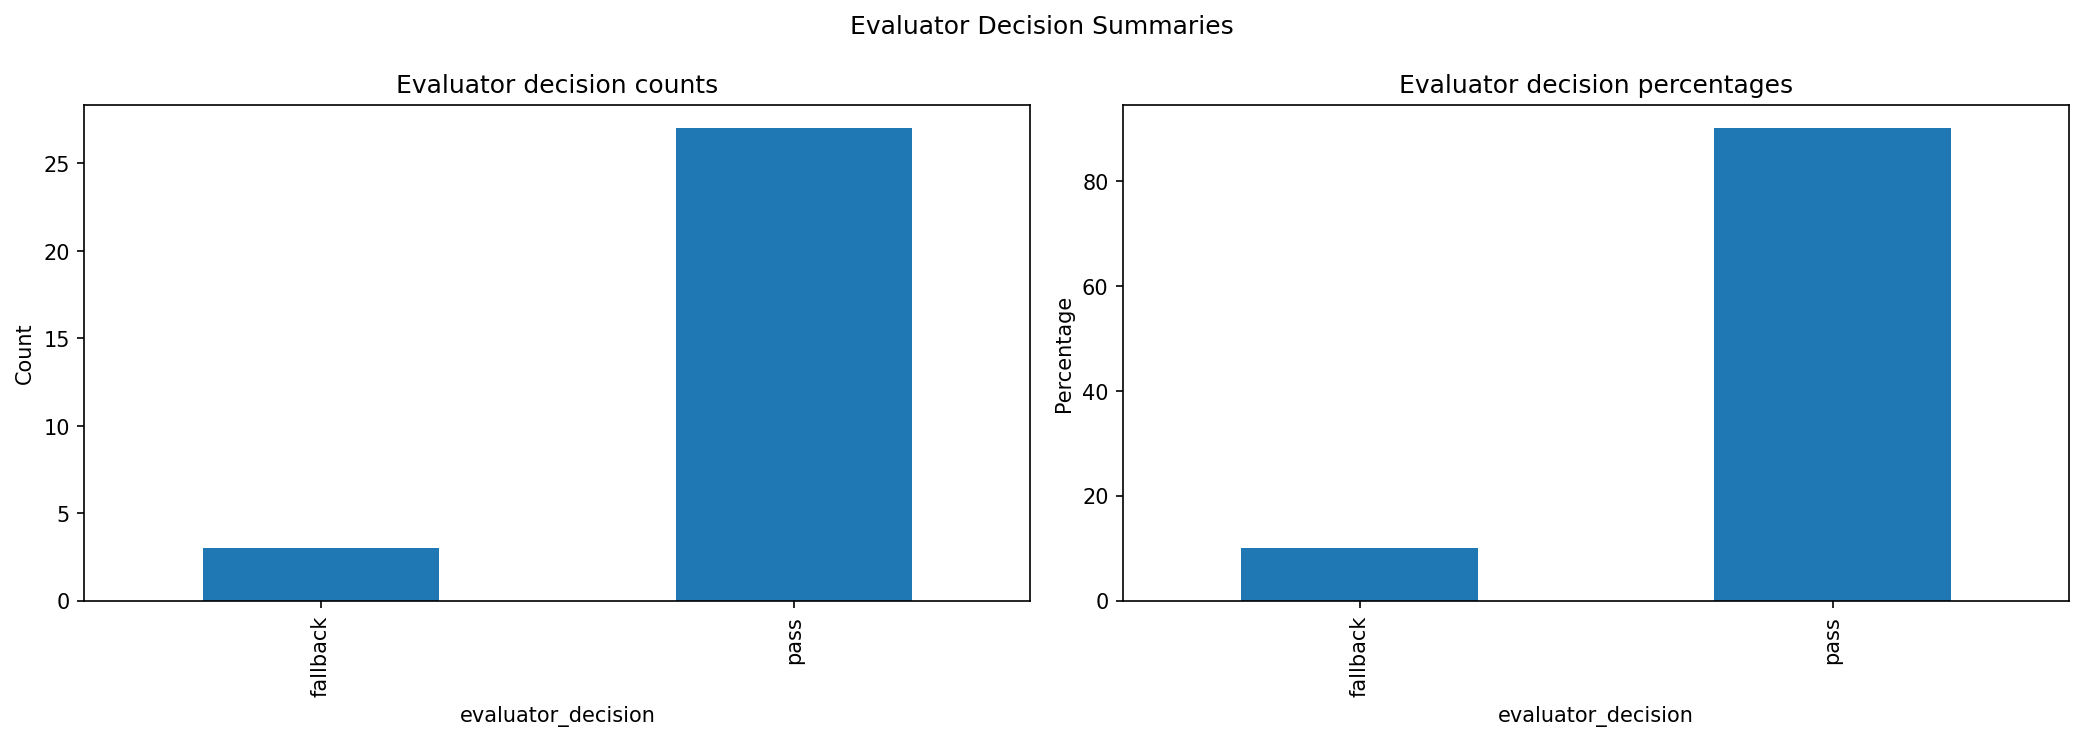

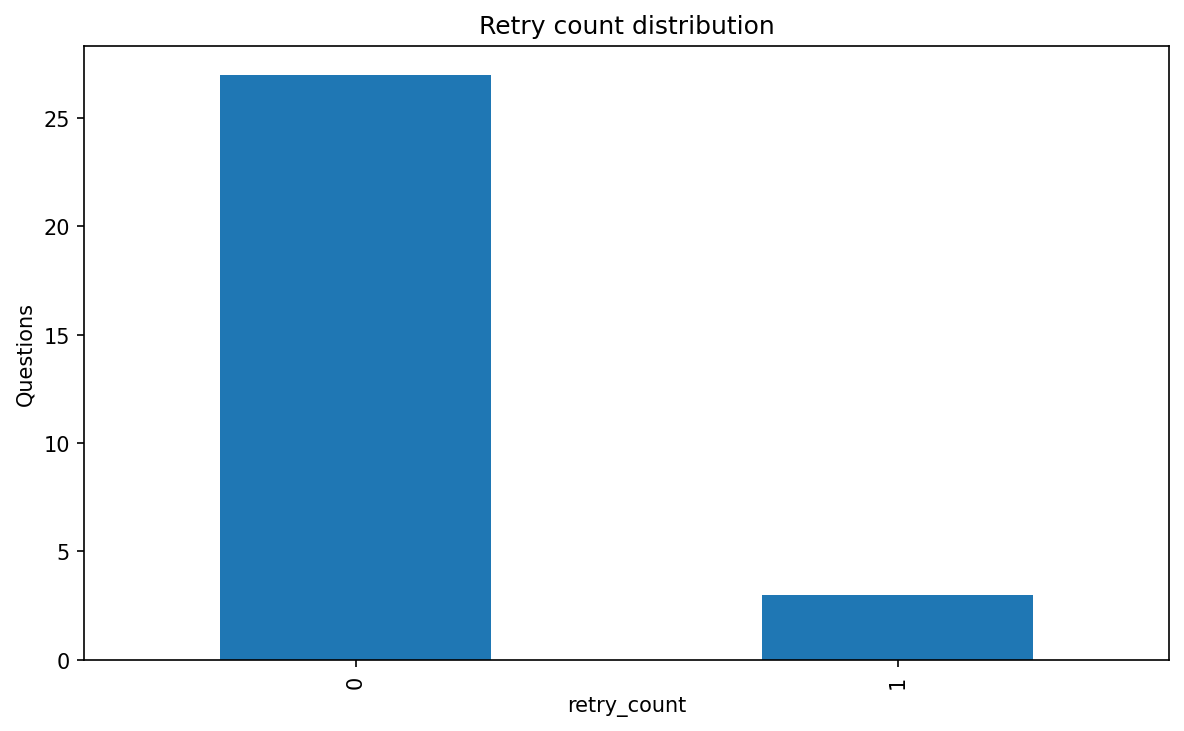

In [4]:
evaluator_df = load_csv_safe(evaluator_path)
display(evaluator_df.head())

if "evaluator_decision" not in evaluator_df.columns:
    print("The evaluator CSV does not contain an 'evaluator_decision' column.")
else:
    decision_counts = evaluator_df["evaluator_decision"].fillna("unknown").astype(str).value_counts().sort_index()
    decision_percentages = decision_counts / max(decision_counts.sum(), 1) * 100.0
    evaluator_summary = pd.DataFrame({"decision": decision_counts.index, "count": decision_counts.values, "percentage": decision_percentages.values})
    display(round_numeric_dataframe(evaluator_summary))

    fig, ax = plt.subplots()
    decision_counts.plot(kind="bar", ax=ax)
    ax.set_title("Evaluator decision counts")
    ax.set_ylabel("Count")
    save_figure(fig, f"{evaluator_path.stem}_decision_counts.png", output_dir=figures_dir, signature_parts=signature_payload("evaluator_decision_counts", decision_counts.to_dict()))

    fig, ax = plt.subplots()
    decision_percentages.plot(kind="bar", ax=ax)
    ax.set_title("Evaluator decision percentages")
    ax.set_ylabel("Percentage")
    save_figure(fig, f"{evaluator_path.stem}_decision_percentages.png", output_dir=figures_dir, signature_parts=signature_payload("evaluator_decision_percentages", decision_percentages.to_dict()))

    retry_values = pd.Series(dtype="float64")
    retry_distribution = pd.Series(dtype="int64")
    if "retry_count" in evaluator_df.columns:
        retry_values = numeric_values(evaluator_df, "retry_count")
        if retry_values.empty:
            print("No numeric retry_count values were available for plotting.")
        else:
            retry_distribution = retry_values.astype(int).value_counts().sort_index()
            display(retry_distribution.rename_axis("retry_count").reset_index(name="questions"))
            fig, ax = plt.subplots()
            retry_distribution.plot(kind="bar", ax=ax)
            ax.set_title("Retry count distribution")
            ax.set_xlabel("retry_count")
            ax.set_ylabel("Questions")
            save_figure(fig, f"{evaluator_path.stem}_retry_distribution.png", output_dir=figures_dir, signature_parts=signature_payload("evaluator_retry_distribution", retry_distribution.to_dict()))
    else:
        print("The evaluator CSV does not contain a 'retry_count' column.")

    overview_fig, overview_axes = plt.subplots(1, 3, figsize=(18, 5))
    decision_counts.plot(kind="bar", ax=overview_axes[0])
    overview_axes[0].set_title("Evaluator decision counts")
    overview_axes[0].set_ylabel("Count")
    decision_percentages.plot(kind="bar", ax=overview_axes[1])
    overview_axes[1].set_title("Evaluator decision percentages")
    overview_axes[1].set_ylabel("Percentage")
    if retry_distribution.empty:
        axis_note(overview_axes[2], "Retry count distribution", "No numeric retry_count values were available.")
    else:
        retry_distribution.plot(kind="bar", ax=overview_axes[2])
        overview_axes[2].set_title("Retry count distribution")
        overview_axes[2].set_xlabel("retry_count")
        overview_axes[2].set_ylabel("Questions")

    overview_fig.suptitle("Evaluator Effectiveness Overview")
    overview_fig.tight_layout()
    save_and_display_figure(overview_fig, build_figure_filename(evaluator_path.stem, "evaluator", "overview"), output_dir=figures_dir, signature_parts=signature_payload("evaluator_overview", {"decision_counts": decision_counts.to_dict(), "decision_percentages": decision_percentages.to_dict(), "retry_distribution": retry_distribution.to_dict()}))

    decisions_fig, decisions_axes = plt.subplots(1, 2, figsize=(14, 5))
    decision_counts.plot(kind="bar", ax=decisions_axes[0])
    decisions_axes[0].set_title("Evaluator decision counts")
    decisions_axes[0].set_ylabel("Count")
    decision_percentages.plot(kind="bar", ax=decisions_axes[1])
    decisions_axes[1].set_title("Evaluator decision percentages")
    decisions_axes[1].set_ylabel("Percentage")

    decisions_fig.suptitle("Evaluator Decision Summaries")
    decisions_fig.tight_layout()
    save_and_display_figure(decisions_fig, build_figure_filename(evaluator_path.stem, "evaluator", "grouped_decisions"), output_dir=figures_dir, signature_parts=signature_payload("evaluator_grouped_decisions", {"decision_counts": decision_counts.to_dict(), "decision_percentages": decision_percentages.to_dict()}))

    if not retry_distribution.empty:
        retry_fig, retry_ax = plt.subplots(figsize=(8, 5))
        retry_distribution.plot(kind="bar", ax=retry_ax)
        retry_ax.set_title("Retry count distribution")
        retry_ax.set_xlabel("retry_count")
        retry_ax.set_ylabel("Questions")
        retry_fig.tight_layout()
        save_and_display_figure(retry_fig, build_figure_filename(evaluator_path.stem, "evaluator", "grouped_retries"), output_dir=figures_dir, signature_parts=signature_payload("evaluator_grouped_retries", retry_distribution.to_dict()))


## Multiple Accuracy Run Comparison

If more than one `accuracy_eval_*.csv` file exists in `results/`, this section compares the runs and saves simple run-to-run comparison figures.

In [5]:
comparison_df = load_accuracy_run_comparison(results_dir=results_dir)

if comparison_df.empty or len(comparison_df) < 2:
    print("Only one accuracy run was found, so run-to-run comparison was skipped.")
else:
    display(round_numeric_dataframe(comparison_df))

    metric_columns = ["avg_faithfulness", "avg_answer_relevancy", "avg_context_precision", "avg_context_recall"]
    available_metric_columns = [column for column in metric_columns if column in comparison_df.columns]
    if available_metric_columns:
        fig, ax = plt.subplots()
        comparison_df.set_index("filename")[available_metric_columns].plot(kind="bar", ax=ax)
        ax.set_title("Accuracy run comparison")
        ax.set_ylabel("Average score")
        save_figure(fig, "accuracy_run_comparison_metrics.png", output_dir=figures_dir, signature_parts=signature_payload("run_comparison_metrics", comparison_df[["filename", *available_metric_columns]]))

    if "avg_total_time_ms" in comparison_df.columns:
        fig, ax = plt.subplots()
        comparison_df.set_index("filename")["avg_total_time_ms"].plot(kind="bar", ax=ax)
        ax.set_title("Average total response time by run")
        ax.set_ylabel("Milliseconds")
        save_figure(fig, "accuracy_run_comparison_total_time.png", output_dir=figures_dir, signature_parts=signature_payload("run_comparison_total_time", comparison_df[["filename", "avg_total_time_ms"]]))

    overview_fig, overview_axes = plt.subplots(1, 2, figsize=(16, 5))
    if available_metric_columns:
        comparison_df.set_index("filename")[available_metric_columns].plot(kind="bar", ax=overview_axes[0])
        overview_axes[0].set_title("Accuracy run comparison")
        overview_axes[0].set_ylabel("Average score")
    else:
        axis_note(overview_axes[0], "Accuracy run comparison", "No average RAGAS columns were available.")

    if "avg_total_time_ms" in comparison_df.columns:
        comparison_df.set_index("filename")["avg_total_time_ms"].plot(kind="bar", ax=overview_axes[1])
        overview_axes[1].set_title("Average total response time by run")
        overview_axes[1].set_ylabel("Milliseconds")
    else:
        axis_note(overview_axes[1], "Average total response time by run", "No avg_total_time_ms column was available.")

    overview_fig.suptitle("Multiple Accuracy Run Comparison")
    overview_fig.tight_layout()
    save_and_display_figure(overview_fig, build_figure_filename("accuracy_run", "comparison", "overview"), output_dir=figures_dir, signature_parts=signature_payload("run_comparison_overview", comparison_df))

    if available_metric_columns:
        metrics_fig, metrics_ax = plt.subplots(figsize=(12, 5))
        comparison_df.set_index("filename")[available_metric_columns].plot(kind="bar", ax=metrics_ax)
        metrics_ax.set_title("Accuracy run metric comparison")
        metrics_ax.set_ylabel("Average score")
        metrics_fig.tight_layout()
        save_and_display_figure(metrics_fig, build_figure_filename("accuracy_run", "comparison", "grouped_metrics"), output_dir=figures_dir, signature_parts=signature_payload("run_comparison_grouped_metrics", comparison_df[["filename", *available_metric_columns]]))


Only one accuracy run was found, so run-to-run comparison was skipped.


## Generated Figure Gallery

Show all figures generated by the notebook in one place.


Evaluation analysis figures
- accuracy_eval_20260414_162339_accuracy_overview.png


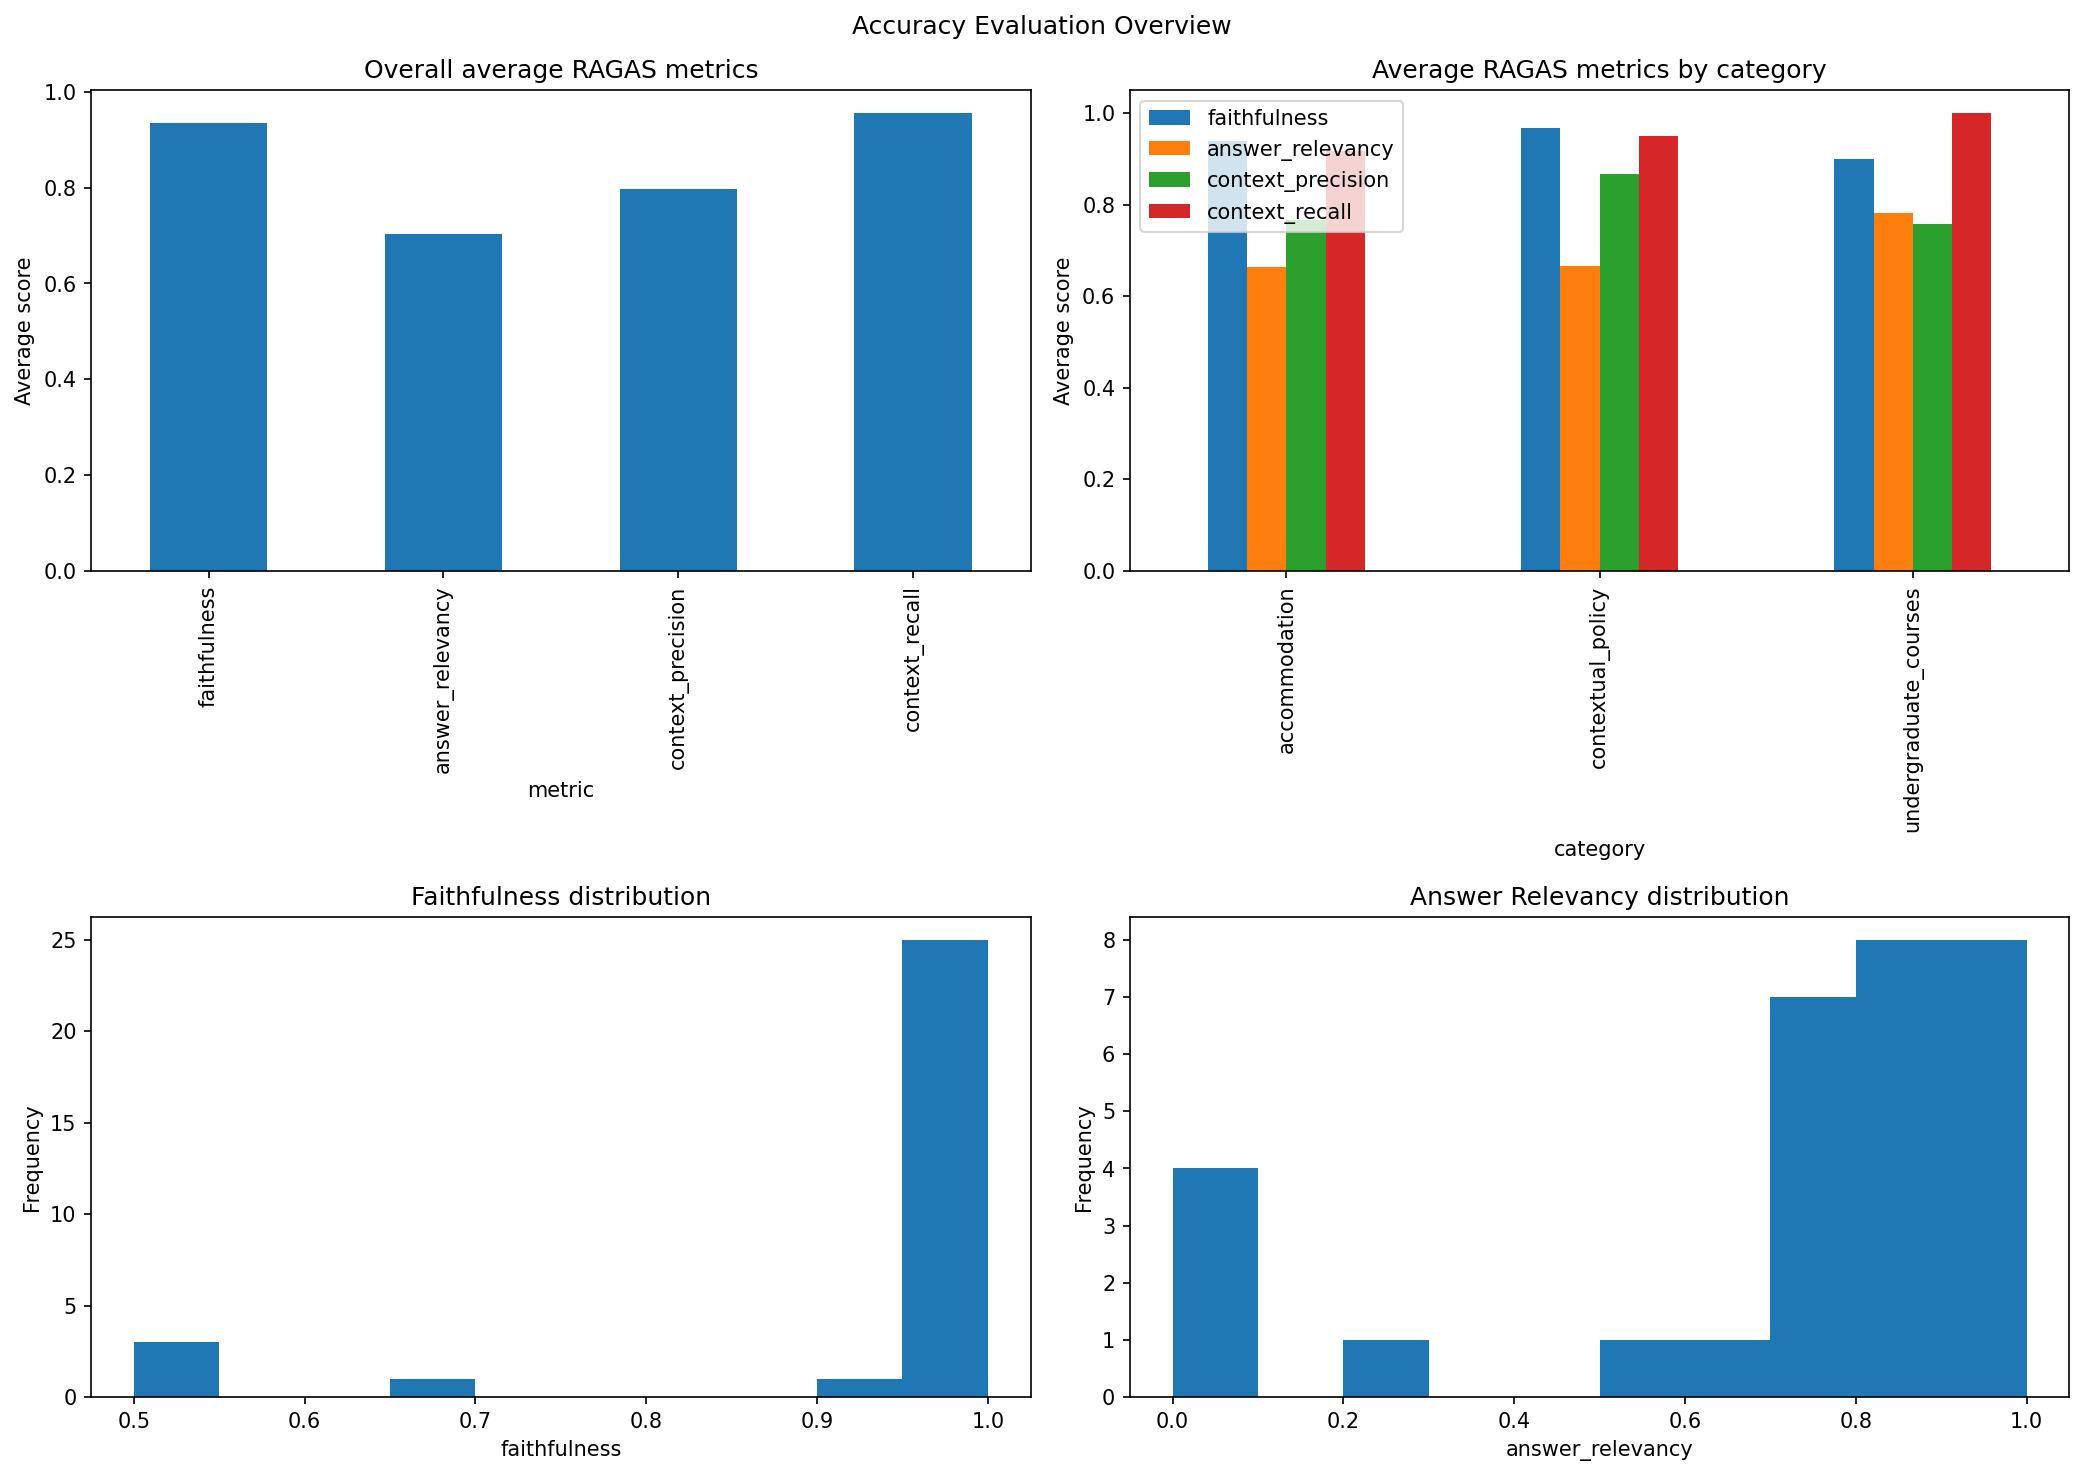

- accuracy_eval_20260414_162339_accuracy_grouped_metrics.png


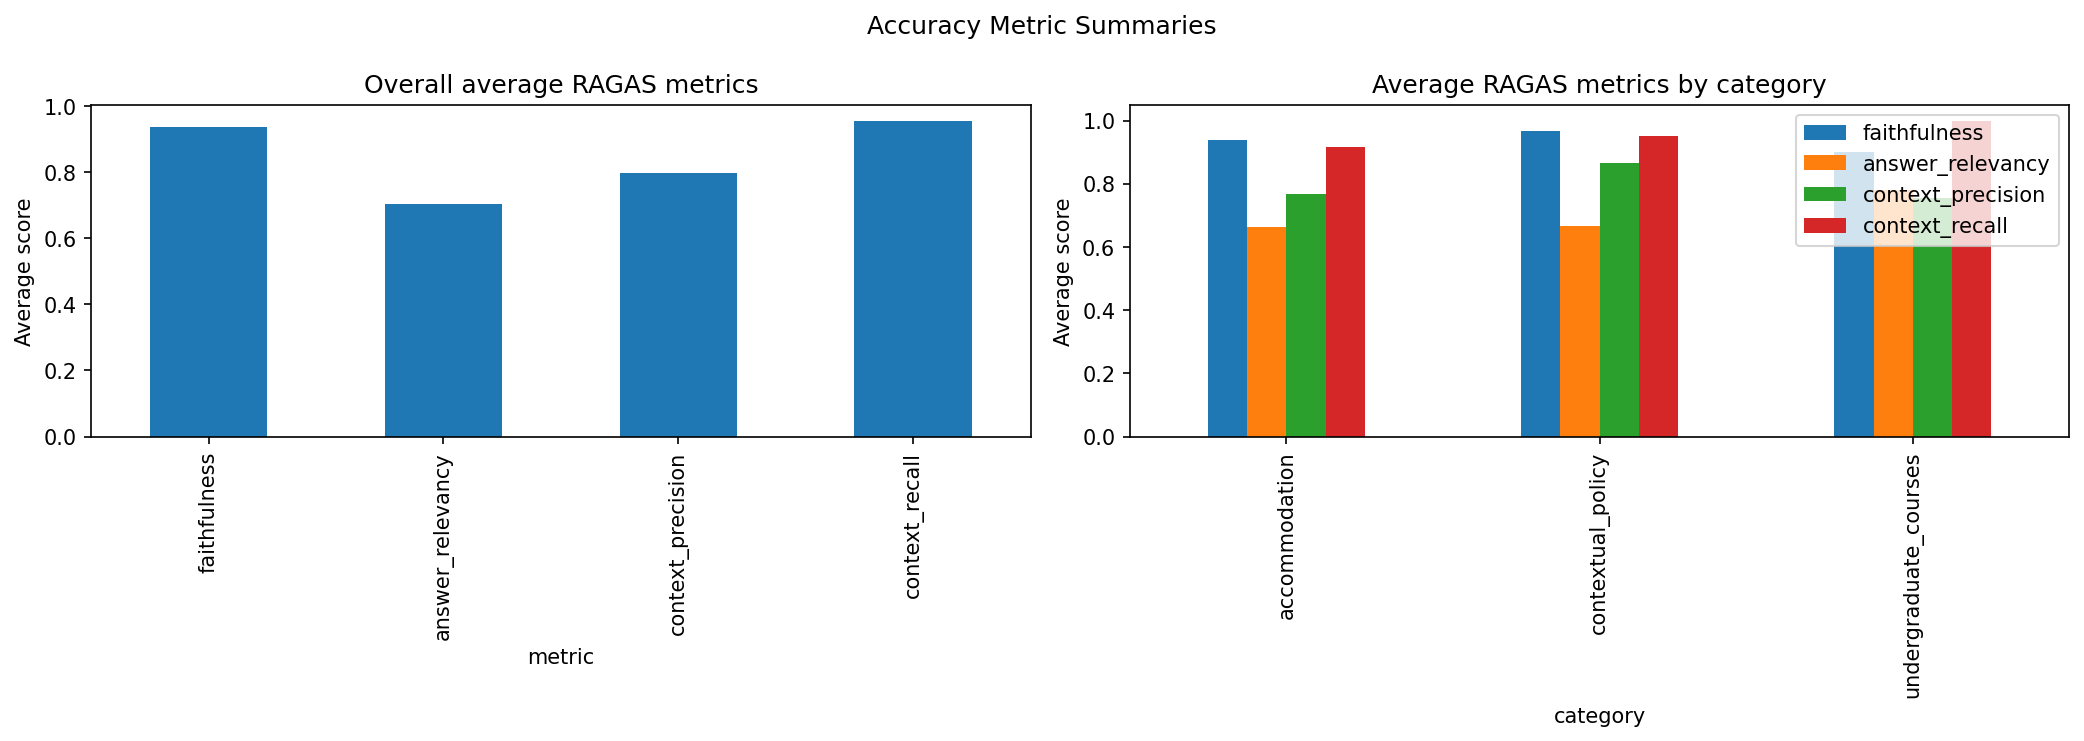

- accuracy_eval_20260414_162339_accuracy_grouped_distributions.png


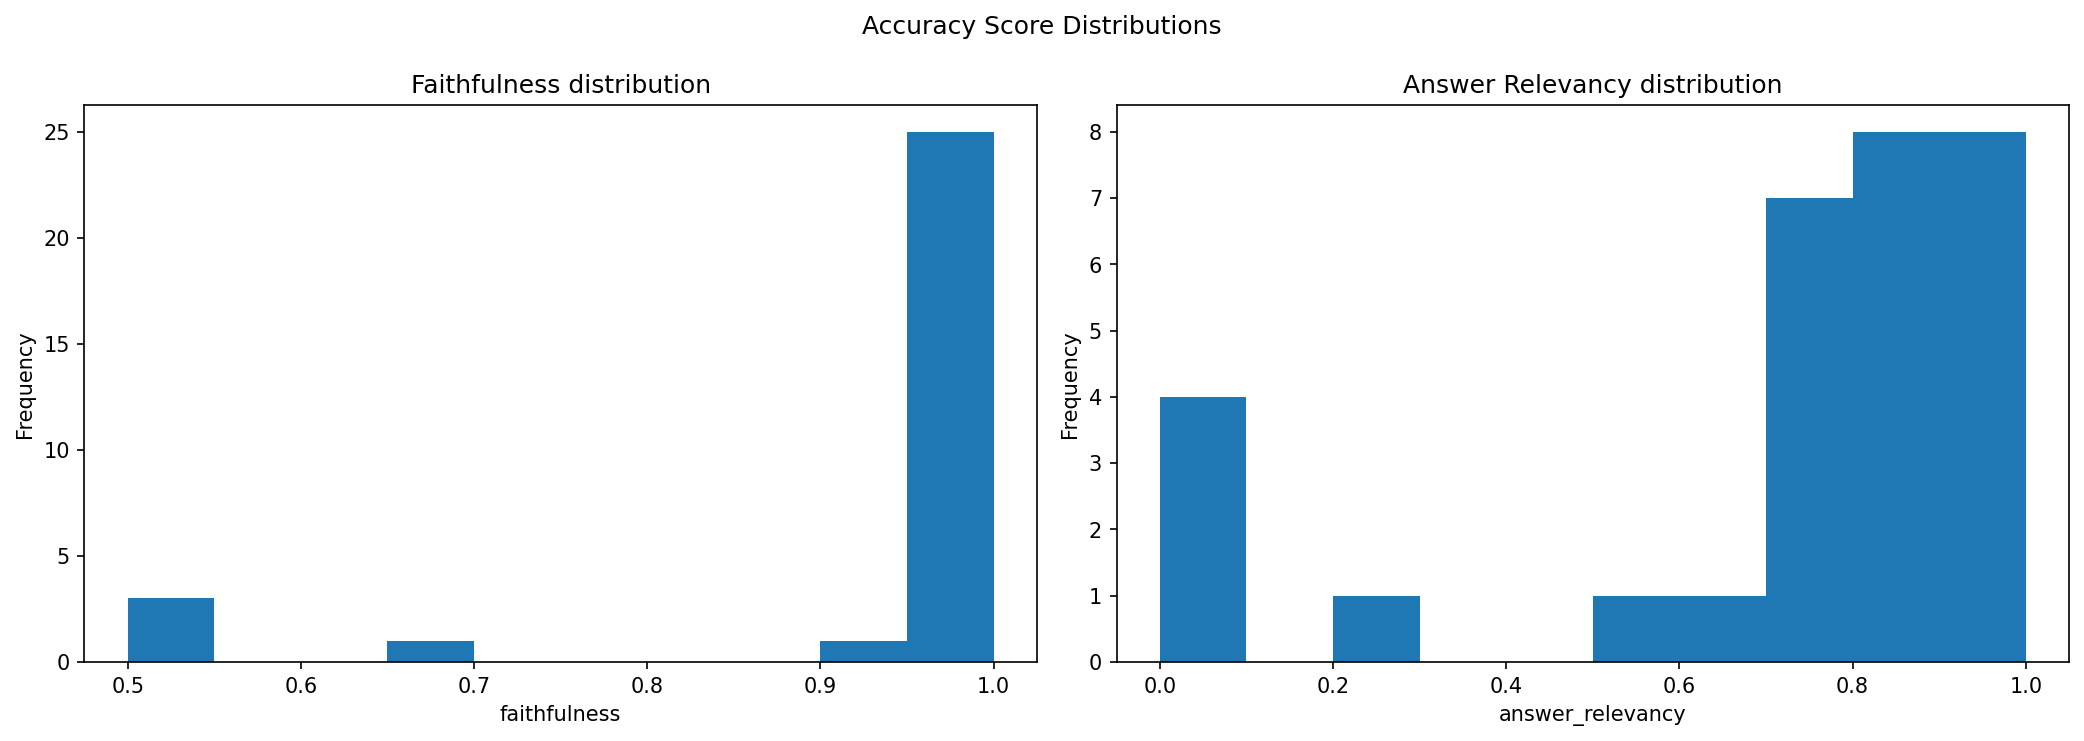

- accuracy_eval_20260414_162339_timing_overview.png


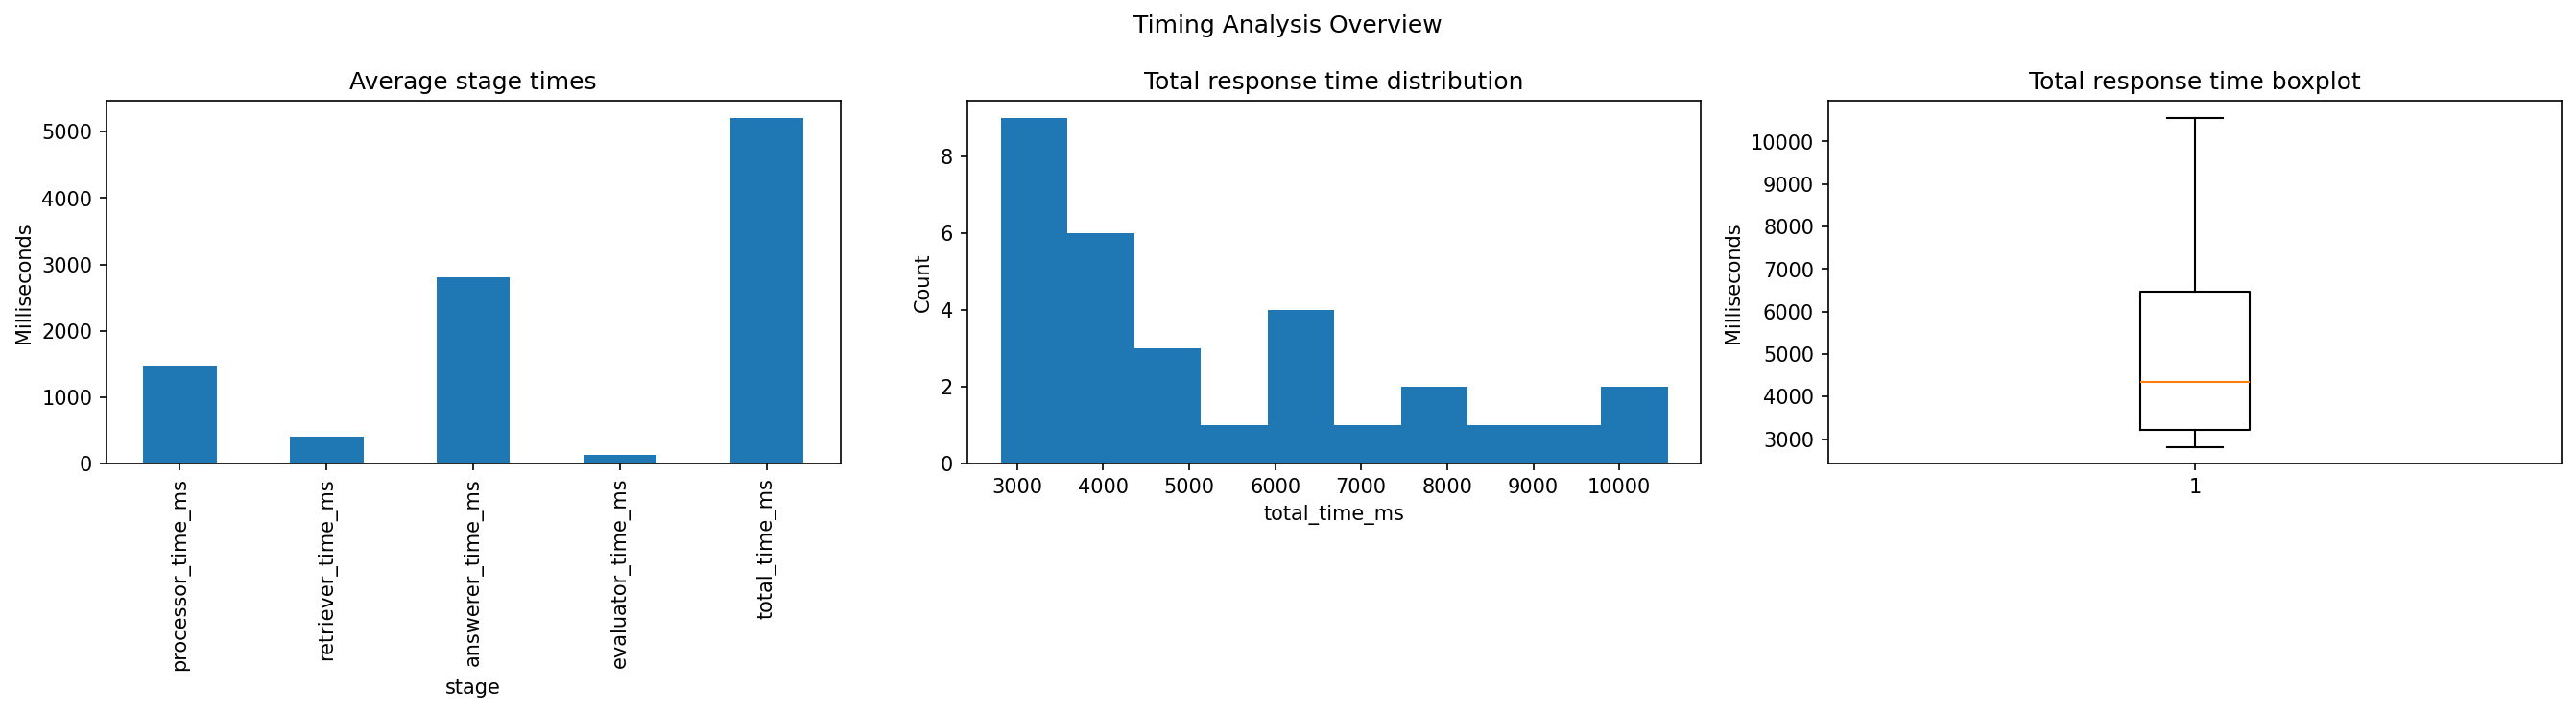

- accuracy_eval_20260414_162339_timing_grouped_distributions.png


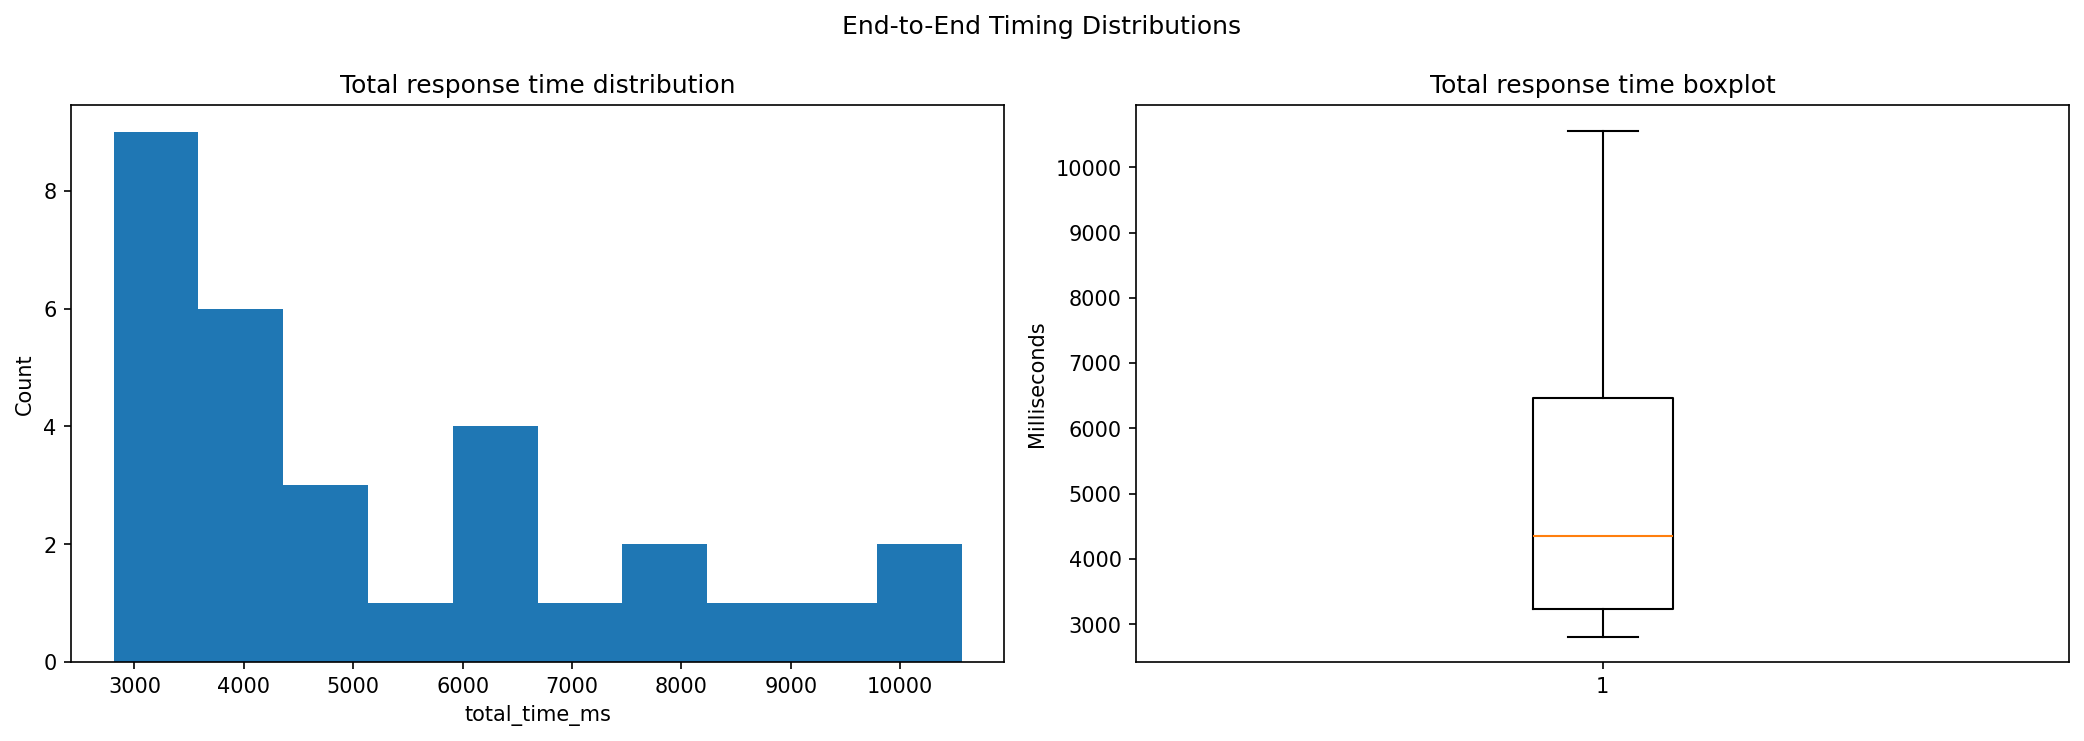

- evaluator_eval_20260414_173926_evaluator_overview.png


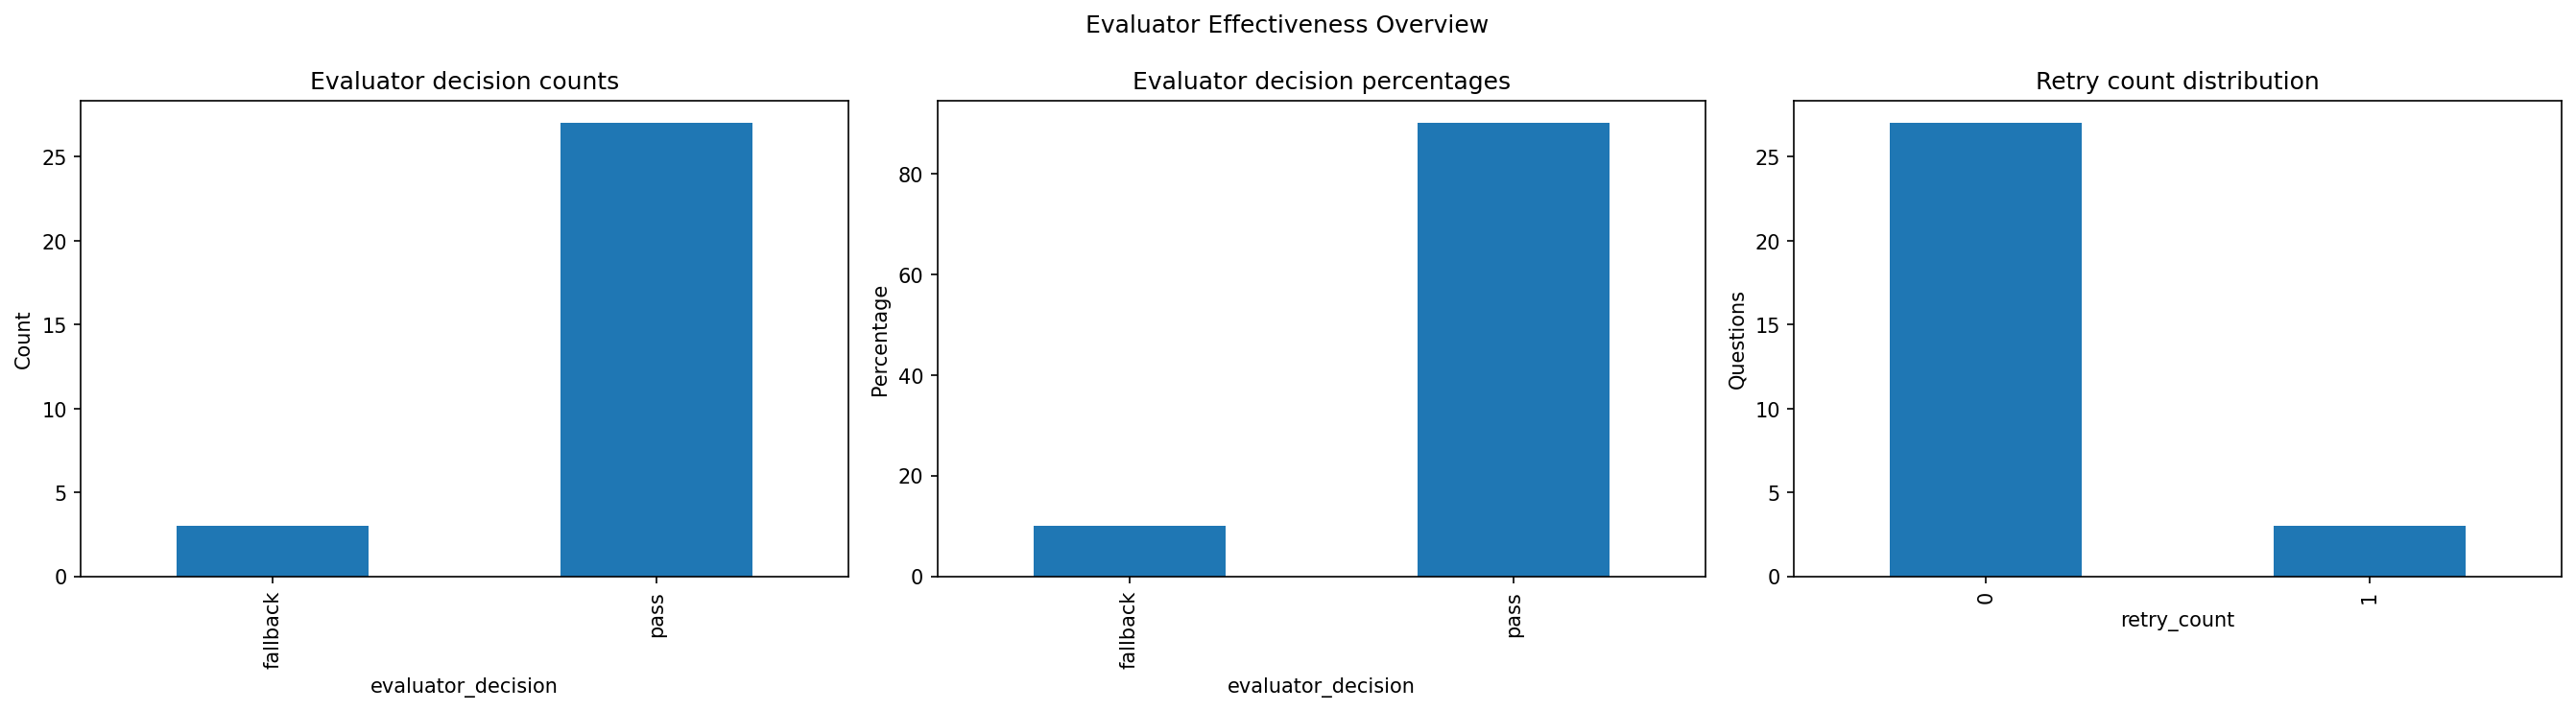

- evaluator_eval_20260414_173926_evaluator_grouped_decisions.png


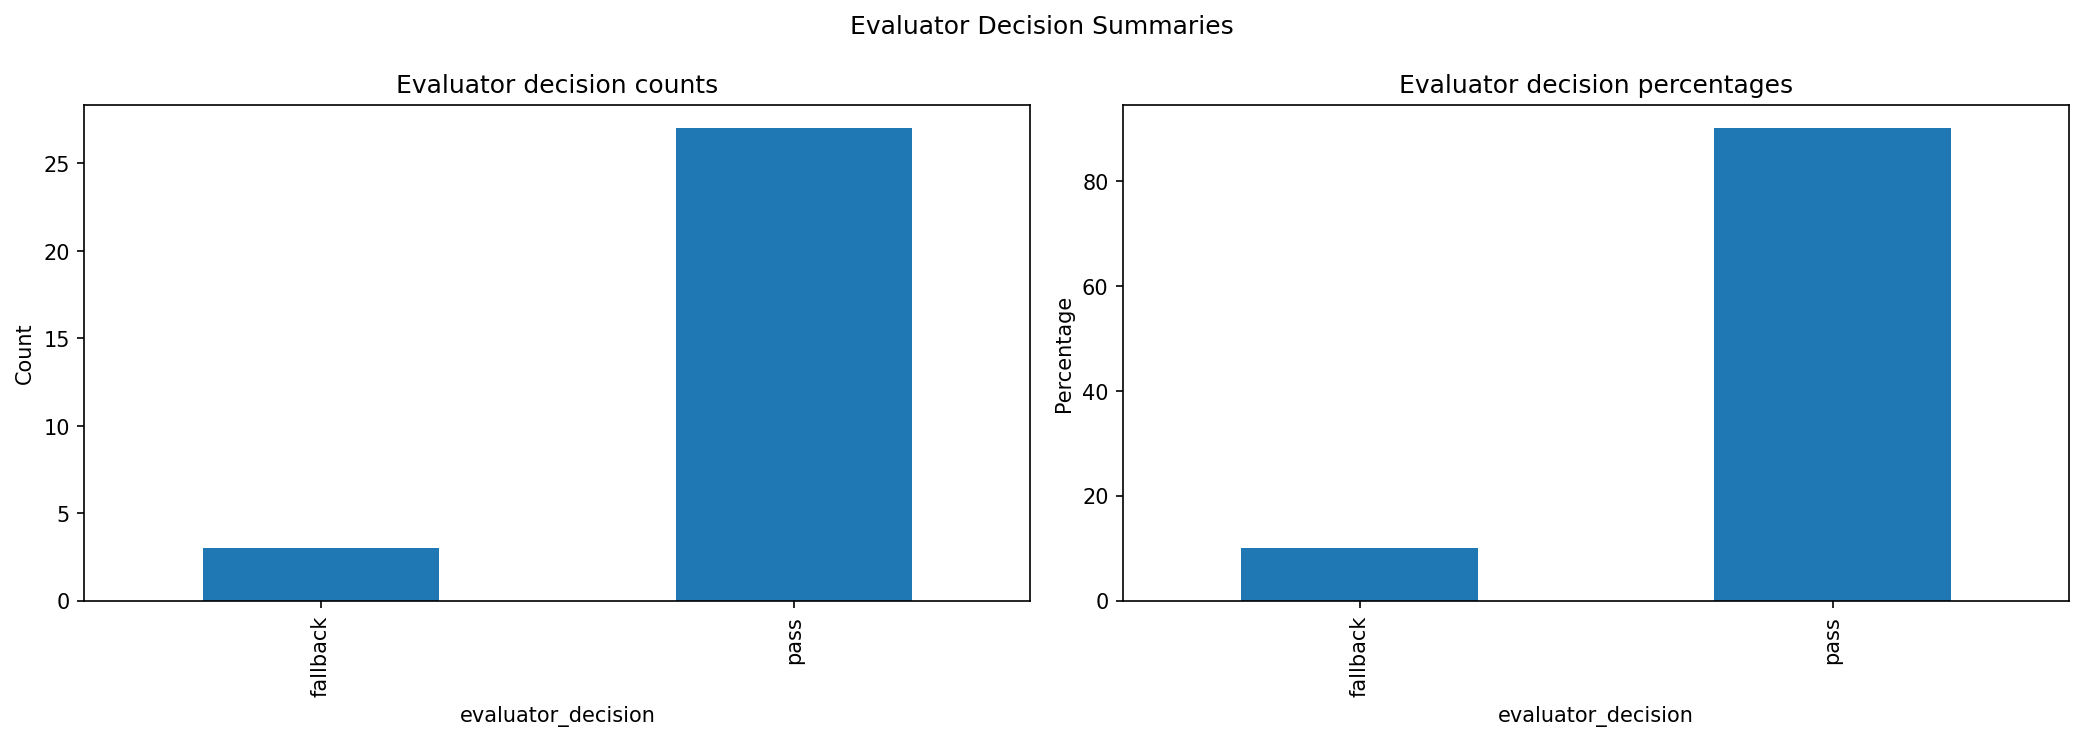

- evaluator_eval_20260414_173926_evaluator_grouped_retries.png


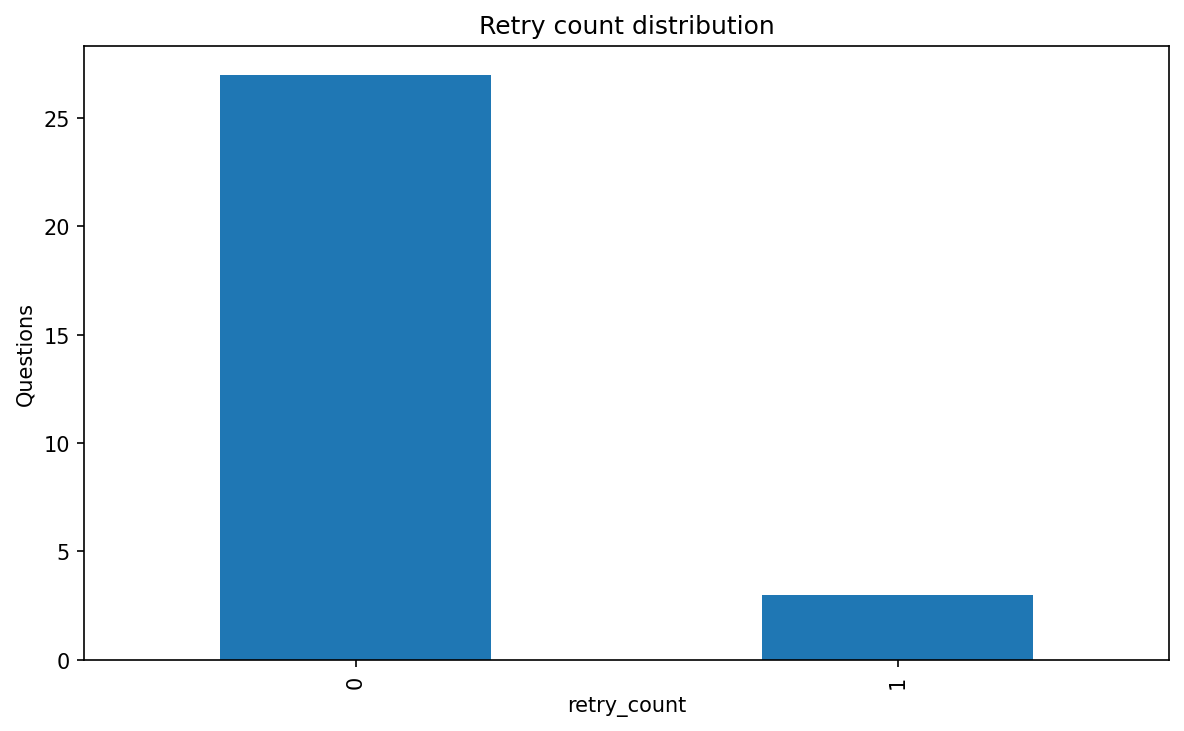

In [6]:
figure_paths = [
    figures_dir / build_figure_filename(accuracy_path.stem, "accuracy", "overview"),
    figures_dir / build_figure_filename(accuracy_path.stem, "accuracy", "grouped_metrics"),
    figures_dir / build_figure_filename(accuracy_path.stem, "accuracy", "grouped_distributions"),
    figures_dir / build_figure_filename(accuracy_path.stem, "timing", "overview"),
    figures_dir / build_figure_filename(accuracy_path.stem, "timing", "grouped_distributions"),
    figures_dir / build_figure_filename(evaluator_path.stem, "evaluator", "overview"),
    figures_dir / build_figure_filename(evaluator_path.stem, "evaluator", "grouped_decisions"),
    figures_dir / build_figure_filename(evaluator_path.stem, "evaluator", "grouped_retries"),
    figures_dir / build_figure_filename("accuracy_run", "comparison", "overview"),
    figures_dir / build_figure_filename("accuracy_run", "comparison", "grouped_metrics"),
]

display_saved_figure_gallery(figure_paths, title="Evaluation analysis figures")
